# 05 (draft) · Second fit, step by step

|                     |     |
| ------------------- | --- |
| **Status**          | Draft |
| **Source**          | Y. Alcaraz Galván; outputs computed from the Tank dataset snapshot (P. Broqvist) and NMR data from experiments; Gogoi et al., J. Phys. Chem. C 2024, 128, 1654 |
| **Scope**           | The second fit (run 2026-10-06 to 2026-10-07): what it settled, what it left open, and why |
| **Builds on**       | `scripts/run_fit.py` (computes every number shown here); results in `notebooks/results/05_fit2/` |
| **See also**        | `05_first_fit.ipynb` (the first fit) · [plan-fit_improvement.md](../docs/plan-fit_improvement.md) (what to change next) · [reference-fitting_system.md](../docs/reference-fitting_system.md) (how a fit runs) |
| **Confidentiality** | Quotes numbers derived from the lab NMR spectra |

**This notebook only loads and shows results.** Nothing is fitted or simulated here. One table is rebuilt from a stored profile: the ranges of the 7-day reading (A.3). The figures are in `demo/fit_plots.py`.

**What changed against the first fit**

- The observables were rebuilt from the raw spectra (first fit: from the share tables of notebook 03).
- The ¹³C spectra of the two water tubes are read (first fit: only their ³¹P). 73 measured values instead of 45.
- Not changed: the model structures, the error model and the rules fixed before fitting.

**Words used here**

- **Tube:** one NMR sample (`sample` in the code and in some figure labels).
- **Age:** time from mixing a tube to its first spectrum. It was not recorded.
- **Reading:** an assumption about the ages (`scenario` in the code). Equal ages of 1 h, 1 day or 7 days, or free ages: each tube has its own.
- **Miss:** (predicted − measured) / standard error of one measured value. A model fits when its worst miss is at most 3.
- **χ²:** the sum of the squared misses.
- **ΔG‡:** the barrier of a reaction, at the temperature where the reaction was seen: 22 °C for R1, R2, R3 and R5, 80 °C for R4 and R8.

| Reaction | | Family |
|---|---|---|
| R1, R2, R3 | TMSPA → BMSPA → MMSPA → H₃PO₄, each step with one H₂O, each releasing one TMSOH | hydrolysis |
| R4 | 2 TMSOH ⇌ HMDSO + H₂O | condensation |
| R5, R6, R7 | the same three steps with TMSOH in place of H₂O, each releasing one HMDSO | transfer |
| R8 | EC + TMSOH ⇌ TMSOEG + CO₂ (ring opening) | solvent attack |

**Assumptions carried through every step**

- Thermochemistry and barrier relations as in notebook 01. The EC/DEC tubes are simulated in EC at 7.1 M, one phase, no DEC.
- Every tube starts from its recipe alone (§4.2 tests this).
- The heating steps of the 2 % tube are taken as 17–18 min each, the minimum the files allow (the paper states 8 h; §5.5).
- All the added water takes part (§5.4 tests this). One water molecule per hydrolysis step.
- The 0.5 % water tube may hold LiPF₆ (notebook 04, Appendix A). It is kept in the fit; §5.3 gives the fit without it.
- ΔS‡ = 0 in every fit (§6.2 varies it).

In [30]:
%load_ext autoreload
%autoreload 2

import sys
from pathlib import Path

# Make the repository importable whether the notebook runs from notebooks/ or from the repository root
REPO = Path.cwd() if (Path.cwd() / 'kinetics').is_dir() else Path.cwd().parent
if str(REPO) not in sys.path:
    sys.path.insert(0, str(REPO))

import numpy as np
import pandas as pd
from IPython.display import display

from kinetics.data import describe_lab_observables, load_lab_observables, tabulate_observable_shares
from kinetics.fitting import FIT_STRUCTURES, get_structure, load_fit_result
from kinetics.fitting.candidates import tabulate_reaction_barriers
from kinetics.fitting.estimation import get_profile_theta
from kinetics.microkinetics.models import LEGACY_MODEL_NAMES
from demo import fit_plots, style, tables

style.apply_style()
pd.set_option('display.max_colwidth', None)
pd.set_option('display.max_rows', 200)

RESULTS = REPO / 'notebooks' / 'results' / '05_fit2'  # the second fit, written by scripts/run_fit.py
FIRST = REPO / 'notebooks' / 'results' / '05'         # the first fit, for the comparisons of §4.1 and A.6
LADDER = list(FIT_STRUCTURES)                        # the structures, simplest first
MAIN = 'M3-split'                                    # the only structure that fits at equal ages (§2)
AGES = {'short': '1 h', 'middle': '1 day', 'long': '7 days', 'free': 'free ages'}   # scenario in the result files → reading
FITTING = ('middle', 'long', 'free')                 # the readings under which M3-split fits
SEEN = ('R1', 'R2', 'R3', 'R5', 'R4', 'R8')          # the reactions the tubes act on
BARRIERS = [f'dG‡ {r}' for r in SEEN]
PANELS = ['0.5 % H2O', '2 % H2O', 'TMSPa + TMSOH (A)', 'TMSOH, probe', 'TMSOH, glovebox', 'E1']
DELTA_CHI2 = 3.84                                    # rise of χ² that ends a 95 % interval


def read(name):
    # Result files written before the rename hold the old model name
    return pd.read_csv(RESULTS / name).replace(LEGACY_MODEL_NAMES)


def by_age(table, scenarios=FITTING):
    # Columns of a table pivoted by scenario: put in order and named by the reading
    return table.reindex(columns=list(scenarios)).rename(columns=AGES).rename_axis(columns='reading')


def show_M(value):
    # A concentration in mol/L as text: 1e-6 becomes '1 µM'
    if not value > 0:
        return 'none'
    return next(f'{value / scale:g} {unit}' for unit, scale in (('mM', 1e-3), ('µM', 1e-6), ('nM', 1e-9)) if value >= 0.999 * scale)


def of_main(table, scenarios=FITTING):
    # Rows of M3-split under the readings where it fits
    return table[(table['structure'] == MAIN) & table['scenario'].isin(scenarios)]


summary, parameters, barriers = read('fits_summary.csv'), read('fits_parameters.csv'), read('fits_barriers.csv')
residuals, intervals = read('fits_residuals.csv'), read('intervals.csv')
traces, trajectories = read('trace_sensitivity.csv'), read('sample_trajectories.csv')
alone, hold_out, later, paper = read('check_tmspa_alone.csv'), read('hold_out.csv'), read('check_later_spectra.csv'), read('check_paper.csv')
loo, sensitivities, same = read('leave_one_out.csv'), read('sensitivities.csv'), read('indistinguishability.csv')
observables = load_lab_observables()
shares = tabulate_observable_shares(observables)


def fitted(structure, scenario='middle'):
    # One row of a composition figure: the best fit of a structure under one reading, labelled with its χ²
    chi2 = summary.set_index(['structure', 'scenario']).loc[(structure, scenario), 'chi2']
    rows = residuals[(residuals['structure'] == structure) & (residuals['scenario'] == scenario)]
    return f'{structure}\n{AGES[scenario]} · χ² ' + f'{chi2:,.0f}'.replace(',', ' '), rows


def measured_shares(sample, spectrum, nucleus='31P'):
    # Shares of one spectrum with the error the fit gives a single spectrum: noise ⊕ baseline ⊕ declared floor
    rows = shares[(shares['sample'] == sample) & (shares['nucleus'] == nucleus) & (shares['spectrum'] == spectrum)].set_index('window')
    floor = observables['_meta']['error_floor'][nucleus]
    floor = np.maximum(floor['absolute'], floor['relative'] * rows['share'].clip(lower=0.0))
    return rows.assign(sigma=np.sqrt(rows['sigma_noise'] ** 2 + rows['sigma_baseline'] ** 2 + floor ** 2))[['share', 'sigma']]


def tabulate_accepted_ranges(scenario):
    # ΔG‡ and ΔG_rxn of each reaction over the accepted sets of M3-split: the fit and every profile point within Δχ² = 3.84 of it
    fit = load_fit_result(str(RESULTS / 'fits' / f'{MAIN}__{scenario}.json'))
    profile = load_fit_result(str(RESULTS / 'profiles' / f'{MAIN}__{scenario}.json'))['profile']
    thetas = [fit['theta']] + [get_profile_theta(row) for _, row in profile[profile['chi2'] - fit['chi2'] <= DELTA_CHI2].iterrows()]
    values = [tabulate_reaction_barriers(get_structure(MAIN), theta) for theta in thetas]
    return pd.DataFrame([{'structure': MAIN, 'scenario': scenario, 'reaction': r,
                          'dG‡ low': min(v[r]['dG_barrier_eV'] for v in values), 'dG‡ high': max(v[r]['dG_barrier_eV'] for v in values),
                          'dG_rxn low': min(v[r]['dG_rxn_eV'] for v in values), 'dG_rxn high': max(v[r]['dG_rxn_eV'] for v in values),
                          'accepted sets': len(thetas) - 1} for r in values[0]])


# Ranges over the accepted sets as stored, except those of the 7-day reading. Its profile measures Δχ² against 47.5, the χ² of that
# fit at the search tolerance; at the report tolerance the fit has 32.4, so the stored ranges count 14 sets too many (A.3)
bands = read('barrier_bands.csv')
bands = pd.concat([bands[~((bands['structure'] == MAIN) & (bands['scenario'] == 'long'))], tabulate_accepted_ranges('long')], ignore_index=True)

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


## 0. The result in one page

```
73 measured values ──► ladder M0 … M3-split ──► M3-split fits under three readings of the ages
                                                              │
                                        same χ², same picture, two different mechanisms
                                                              │
                              tests that could choose: a trace of TMSOH, the tubes that were not fitted
                                                              │
                                          no reading passes every test ──► third fit
```

- **Structure.** At equal ages only M3-split fits: R1 separate from R2–R3, and the reaction energies of R1–R4 free (§2).
- **Settled**, the same under the three readings that fit (§3, §5):
  - ΔG‡ of solvent attack 1.29 eV and of condensation 1.24 eV, at 80 °C;
  - ΔG‡ of the second and third hydrolysis, 0.96–1.07 eV at 22 °C;
  - the reaction energies of R1–R4: about −0.05, +0.04, +0.08 and −0.16 eV, against −0.47, −0.16, −0.18 and +0.10 eV computed.
- **Condition on all of these except solvent attack:** at least 60 % of the water added to the 2 % tube took part (§5.4).
- **Not settled:** how TMSPA is consumed. ΔG‡(R1) is 1.31, 1.67 or 1.09 eV and ΔG‡(R5) is 0.59, 0.55 or 0.90 eV, with the same χ² (32.7, 32.4, 30.4).
- **The new ¹³C spectra did not choose a reading** (§4.1). They fixed the energy of condensation.
- **Every reading fails a test** (figure): equal ages fail when a trace of TMSOH is present at mixing; free ages fail the tube "TMSPa alone".

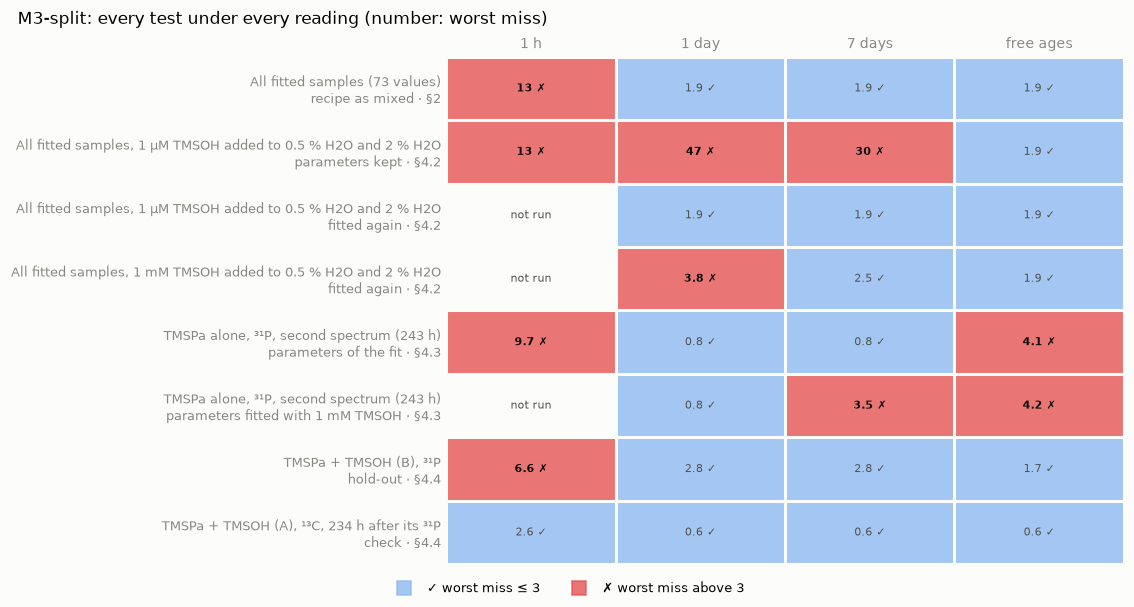

In [31]:
worst_of = lambda table: of_main(table, AGES).groupby('scenario')['z'].apply(lambda z: z.abs().max())
kept = traces[traces['parameters'] == 'as fitted without it'].set_index(['TMSOH at mixing (M)', 'scenario'])['max |z|']
again = traces[traces['parameters'] == 'fitted again'].set_index(['TMSOH at mixing (M)', 'scenario'])['max |z|']
alone_best = of_main(alone, AGES).groupby(['parameters', 'scenario'])['max |z|'].min()       # the most favourable of the three starts
verdicts = pd.DataFrame({
    'All fitted samples (73 values)\nrecipe as mixed · §2': of_main(summary, AGES).set_index('scenario')['max |z|'],
    'All fitted samples, 1 µM TMSOH added to 0.5 % H2O and 2 % H2O\nparameters kept · §4.2': kept[1e-6],
    'All fitted samples, 1 µM TMSOH added to 0.5 % H2O and 2 % H2O\nfitted again · §4.2': again[1e-6],
    'All fitted samples, 1 mM TMSOH added to 0.5 % H2O and 2 % H2O\nfitted again · §4.2': again[1e-3],
    'TMSPa alone, ³¹P, second spectrum (243 h)\nparameters of the fit · §4.3': alone_best['the fit'],
    'TMSPa alone, ³¹P, second spectrum (243 h)\nparameters fitted with 1 mM TMSOH · §4.3': alone_best['fitted with TMSOH 1mM at mixing'],
    'TMSPa + TMSOH (B), ³¹P\nhold-out · §4.4': worst_of(hold_out),
    'TMSPa + TMSOH (A), ¹³C, 234 h after its ³¹P\ncheck · §4.4': worst_of(later)}).T.reindex(columns=list(AGES)).rename(columns=AGES)
fit_plots.plot_verdicts(verdicts, title=f'{MAIN}: every test under every reading (number: worst miss)');

**How to read it:** one row per test, one column per reading. The number is the worst miss of that test. ✓: within the fit rule (at most 3). ✗: above it. A reading is acceptable only if its whole column is ✓.

**Row labels:** first line, the samples scored, named as in the observables file (table of §1.1); second line, what is changed.

- **All fitted samples:** `0.5 % H2O`, `2 % H2O`, `TMSPa + TMSOH (A)` (³¹P), `TMSOH, probe`, `TMSOH, glovebox` and the published limit `E1`.
- **Not fitted:** `TMSPa alone`, `TMSPa + TMSOH (B)` and the ¹³C spectrum of `TMSPa + TMSOH (A)`.
- In the text, "tube A" and "tube B" are `TMSPa + TMSOH (A)` and `(B)`; "the 0.5 % tube" and "the 2 % tube" are `0.5 % H2O` and `2 % H2O`.

| § | Question | Answer |
|---|---|---|
| 1 | What does the fit read? | 73 values from five tubes and one published limit. No age was recorded |
| 2 | Which structure fits? | M3-split, at 1 day, 7 days and with free ages. With free ages M3 also fits |
| 3 | What did it find? | Four barriers and four energies that do not depend on the reading; two barriers that do |
| 4 | Which reading is right? | None passes every test |
| 5 | How firm is the settled part? | Solvent attack is firm. Every other value rests on one or two tubes, and on the water of the 2 % tube |
| 6 | What does it predict? | Storage at 25 °C: 90 % of the water gone after 9 days to 11 months |
| 7 | What next? | The third fit: free ages as the base, "TMSPa alone" in the fit, the trace test as a rule |

## 1. What the fit reads

**What this part delivers:** the 73 measured values that every model is compared with, and the one unknown that is carried through the whole notebook: the age of the tubes.

```
five tubes + one published limit  ──►  73 values ± error
```

### 1.1 The tubes

- **What:** five lab tubes and one limit taken from the paper (E1). Each tube gives the area shares of its spectra.
  - ³¹P: the phosphates TMSPA, BMSPA, MMSPA, H₃PO₄.
  - ¹³C: the silyl groups, as TMSOH, HMDSO, TMSOEG (ring-opened EC) and P-silyl (still bound to phosphate).
- **New in the second fit:** the ¹³C spectra of the two water tubes.
- **Table:** what was mixed and what is known of the history. The role says how a tube is used: `fit`, `hold_out` (predicted afterwards) or `check`. **Figure:** the measured shares of the fitted tubes.

,role,spectra,solutes at t = 0,before the first spectrum,heated after the first spectrum
0.5 % H2O,fit,1 31P + 1 13C,"TMSPA 149 mM, H2O 263 mM",unknown (age),—
2 % H2O,fit,6 31P + 6 13C,"TMSPA 149 mM, H2O 1052 mM",unknown (age),"30 °C × 17 min, 40 °C × 17 min, 50 °C × 18 min, 60 °C × 18 min, 70 °C × 17 min, 80 °C × 18 min"
TMSPa + TMSOH (A),fit,1 31P + 1 13C (check),"TMSPA 149 mM, TMSOH 180 mM",unknown (age),—
TMSPa + TMSOH (B),hold_out,1 31P,"TMSPA 149 mM, TMSOH 180 mM",unknown (age),—
TMSPa alone,check,2 31P,TMSPA 149 mM,unknown (age),—
"TMSOH, probe",fit,3 13C,TMSOH 450 mM,unknown (age),80 °C × 9 min
"TMSOH, glovebox",fit,1 13C,TMSOH 450 mM,80 °C × 8 h,—


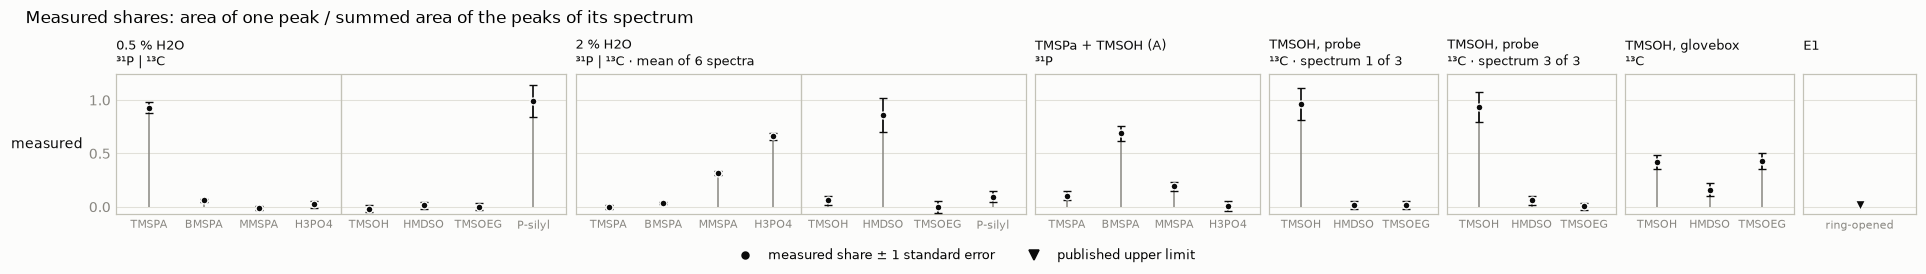

In [32]:
display(describe_lab_observables(observables)[['role', 'spectra', 'solutes at t = 0', 'before the first spectrum', 'heated after the first spectrum']])
fit_plots.plot_compositions({'measured': fitted(MAIN)[1]}, PANELS[:3] + [('TMSOH, probe', 1), ('TMSOH, probe', 3)] + PANELS[4:], predicted=False,
                            title='Measured shares: area of one peak / summed area of the peaks of its spectrum');

| Fact | What is measured | Tube |
|---|---|---|
| **A** | TMSOH leaves EC alone at room temperature: at most 3 % ring-opened over six days, and less than 2 % in a week in the paper. At 80 °C it opens EC: 43 % ring-opened after 8 h | TMSOH probe, E1, TMSOH glovebox |
| **B** | TMSPA survives with 0.5 % water (93 % left) and is gone with 2 % water | the two water tubes |
| **C** | The 2 % tube rests at 66 % H₃PO₄, 32 % MMSPA, 4 % BMSPA. Six spectra over 145 h show the same shares, heating steps up to 80 °C included | 2 % water |
| **D** | With TMSOH and no added water, 69 % of the phosphate is BMSPA and 19 % MMSPA: TMSOH removes silyl groups | TMSPA + TMSOH, tube A |
| **E** (new) | In the 2 % tube 86 % of the silyl groups are HMDSO, 6 % TMSOH and 10 % still on phosphate. In the 0.5 % tube all of them are still on phosphate | ¹³C of the two water tubes |

**The two nuclei agree.** The ³¹P shares of the 2 % tube imply 13 % of the silyl groups still on phosphate; ¹³C measures 10 ± 5 %.

**How the 73 values are counted**

- **0.5 % water** 8 (4 ³¹P + 4 ¹³C), **tube A** 4, **TMSOH probe** 9 (three spectra), **TMSOH glovebox** 3, **E1** 1.
- **2 % water** 48. Per nucleus, its six spectra count as one composition (4 values) and 20 measurements of "no change". Their scatter is 1.72 (³¹P) and 2.86 (¹³C) times what the spectral noise allows, so their noise is multiplied by that factor.
- **Kept out of the fit:** tube B (same recipe as tube A), TMSPa without added water, and the ¹³C spectrum of tube A taken 234 h after its ³¹P. They are the checks of §4.3 and §4.4.
- **No fitted tube was followed while it reacted.** Every fitted share is a snapshot. The one tube seen moving, "TMSPa alone", is not fitted.

--> The models are compared with 73 numbers. 1.2 adds the unknown that every fit depends on.

### 1.2 The unknown age

- **Problem:** no mixing time is recorded. The age of a tube is unknown for four of the five tubes. Only the glovebox tube has a known history (8 h at 80 °C).
- **Way out:** every fit is made four times, each under one reading of the ages.

| Name in the result files | Shown here as | Reading |
|---|---|---|
| `short` | **1 h** | every tube was 1 h old at its first spectrum |
| `middle` | **1 day** | every tube was 1 day old |
| `long` | **7 days** | every tube was 7 days old |
| `free` | **free ages** | each tube has its own age, between 1 h and 30 days, chosen by the fit to favour the model |

- **How to use it:** a value that is the same under every reading is set by the data. A value that changes with the reading is set by the assumption.

--> §1 hands to §2 the 73 values and the four readings.

## 2. Which structure fits: the ladder

**What this part delivers:** the simplest structure that the data do not reject, and the fact that rejects each simpler one.

- **Structure:** a model with its barrier values left free for the fit. **Ladder:** each structure adds freedom to the one before.

| Rung | Structure | Free parameters | What it adds |
|---|---|---|---|
| 1 | M0 | 1 | one barrier for all nine reactions: the structure of `reference_bep` |
| 2 | M1 | 4 | one barrier per family: the structure of `level1` |
| 3 | M1-split | 5 | R1 separate from R2 and R3 |
| 4 | M3 | 8 | M1 with the reaction energies of R1–R4 free |
| 5 | M3-split | 9 | both additions together |

**How a fit is scored**

- **Standard error of a share:** noise ⊕ baseline spread ⊕ a declared floor (³¹P: the larger of 0.01 and 5 %; ¹³C: the larger of 0.03 and 15 %).
- **Fit rule, fixed before any fit:** a structure fits if its worst miss is 3 or less.
- **A freed energy is held by its computed value:** "ΔG_rxn = computed ± standard error" counts as one more value, so a shift is a miss like any other. M3 and M3-split are scored on 73 + 4 = 77 values.

### 2.1 The ladder in one picture

- **Table:** χ² (worst miss) of each structure under each reading.
- **Figure:** the worst miss of every structure under every reading. A structure fits where its point is inside the grey band.

"χ² (worst miss), ✓ = fits",free parameters,1 h,1 day,7 days,free ages
M0-BEP,1 (+1 age if free),3914 (60.1) ✗,3913 (60.1) ✗,3909 (60.0) ✗,3848 (57.7) ✗
M0-Marcus,1 (+1 age if free),3968 (59.8) ✗,3965 (59.7) ✗,3947 (59.3) ✗,3821 (56.4) ✗
M1,4 (+1 age if free),1698 (21.0) ✗,1579 (18.5) ✗,677 (19.7) ✗,561 (15.6) ✗
M1-split,5 (+1 age if free),1543 (22.0) ✗,412 (16.1) ✗,379 (15.9) ✗,275 (13.0) ✗
M3,8 (+1 age if free),665 (13.5) ✗,324 (10.6) ✗,261 (10.4) ✗,49 (2.5) ✓
M3-split,9 (+1 age if free),660 (13.4) ✗,33 (1.9) ✓,32 (1.9) ✓,30 (1.9) ✓


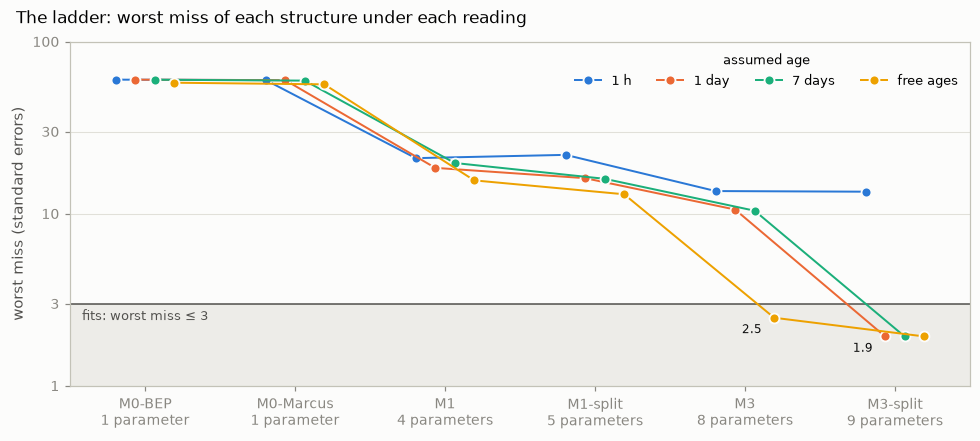

In [33]:
fit_plots.plot_ladder(summary, order=LADDER, title='The ladder: worst miss of each structure under each reading');
ordered = summary.assign(structure=pd.Categorical(summary['structure'], LADDER)).sort_values('structure')
tables.format_structure_table(ordered.assign(structure=ordered['structure'].astype(str))).rename(columns=AGES).rename_axis('χ² (worst miss), ✓ = fits', axis=1)

**Result**

| Structure | Fits? | Rejected by |
|---|---|---|
| M0 | no | fact A against B and D: one barrier cannot be slow for solvent attack and fast for hydrolysis |
| M1 | no | facts B and C: one hydrolysis barrier, and energies that send hydrolysis to the end |
| M1-split | no | fact C: the computed energies send hydrolysis to the end |
| M3 | with free ages only (worst miss 2.5) | at equal ages, facts B and D: one hydrolysis barrier cannot serve R1 and R2–R3 |
| M3-split | yes, at 1 day, 7 days and with free ages (worst miss 1.9) | — |

- **At equal ages both changes are needed together.** At 1 day the split alone gives χ² 412 (worst miss 16.1), free energies alone 324 (10.6), both 32.7 (1.9).
- **With free ages the split is not needed.** M3 fits (χ² 49.4, worst miss 2.5). In the first fit it missed the rule by 0.06.
- **At 1 h nothing fits** (worst miss 13.4): one hour is not enough time for the tubes to react as observed.
- **By the rule fixed before fitting** (the smallest structure that fits, equal ages before free ages) the first consistent set is M3-split at 7 days (χ² 32.4), with 1 day (32.7) just behind. The data cannot tell the two apart.

--> Only M3-split fits at equal ages. 2.2 shows what each simpler rung gets wrong.

### 2.2 What each rung gets wrong

- **Figure:** the six panels of §1.1, one row per rung, under the 1-day reading.
  - Dot: measured. Bar: predicted. A red bar is a miss above 3, with the miss written over it.
  - In the two water tubes the ³¹P shares are left of the rule and the ¹³C shares right of it.

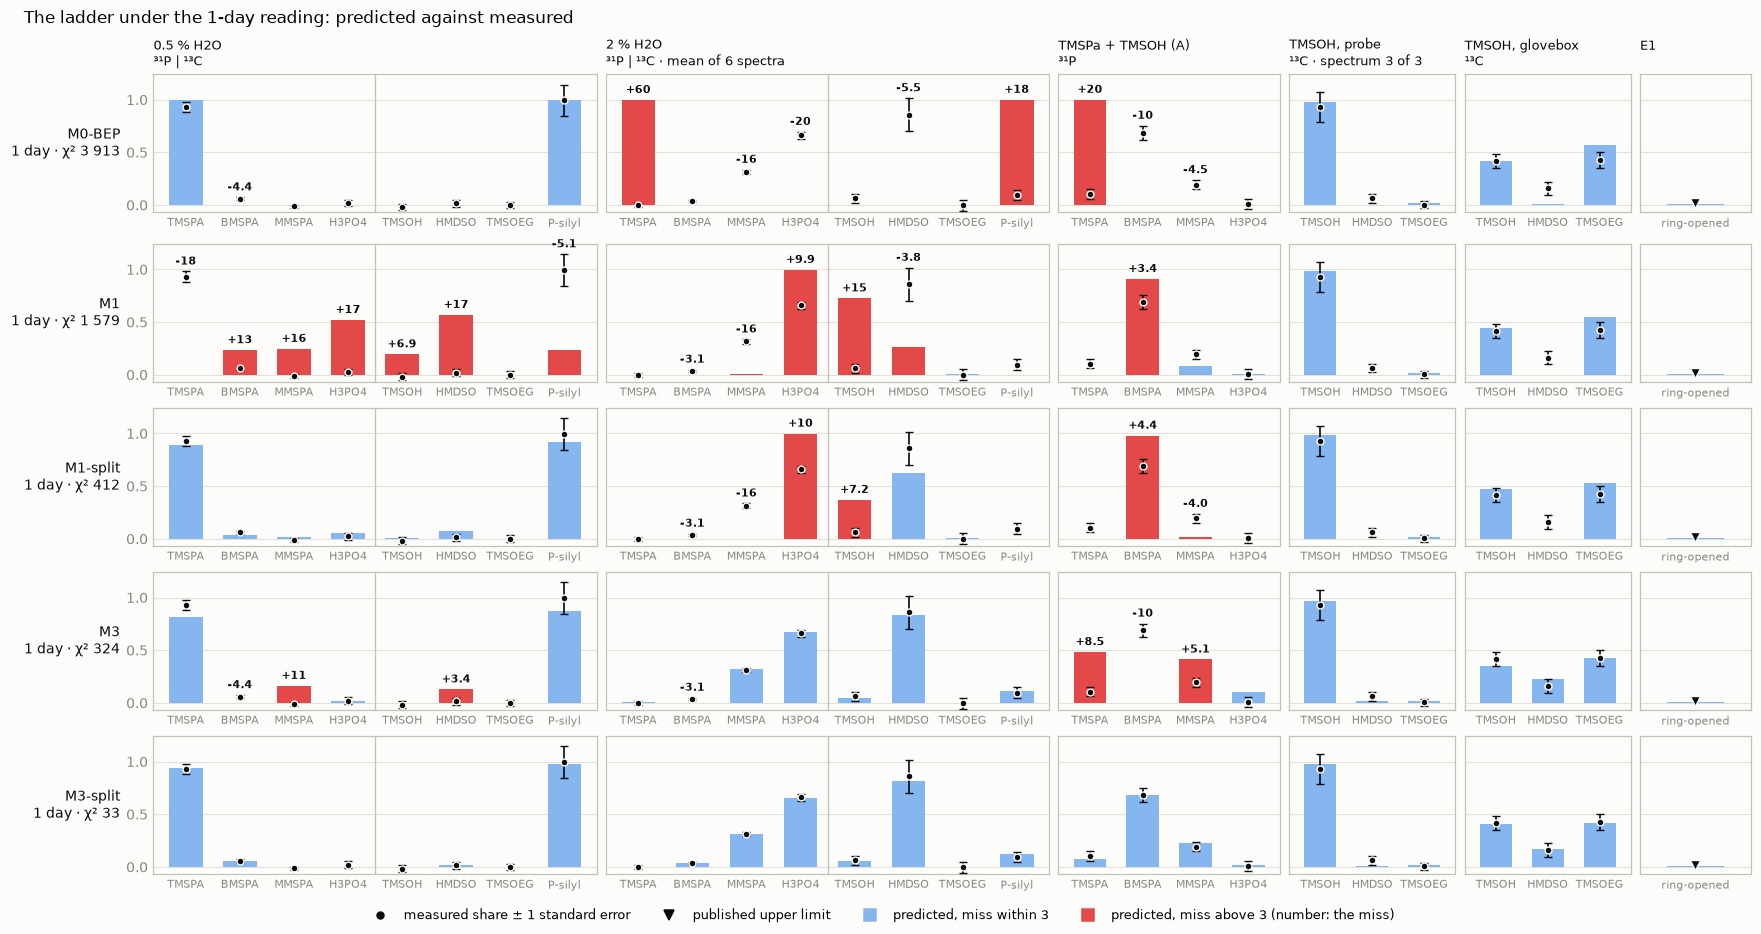

In [34]:
fit_plots.plot_compositions(dict(fitted(structure) for structure in ('M0-BEP', 'M1', 'M1-split', 'M3', MAIN)), PANELS,
                            title='The ladder under the 1-day reading: predicted against measured');

**Result**

- **M0, one barrier (1.28 eV):** nothing reacts at room temperature. The 2 % tube is predicted as 100 % TMSPA (miss 60) and so is tube A (miss 20). A barrier low enough to consume TMSPA would let TMSOH open EC, which fact A forbids.
- **M1, one barrier per family:** the TMSOH tubes are described. Hydrolysis has one speed for both water tubes: the best compromise hydrolyses the 0.5 % tube as well (no TMSPA predicted where 93 % is measured, miss 18) and still sends the 2 % tube to 100 % H₃PO₄ (MMSPA miss 16).
- **M1-split, R1 separate:** the 0.5 % tube is right. The 2 % tube still ends at 100 % H₃PO₄ where 32 % MMSPA is measured (miss 16): with the computed energies hydrolysis cannot stop partway.
- **M3, energies free:** the 2 % tube rests where it is measured. The single hydrolysis barrier now fails the other two phosphate tubes: 16 % MMSPA predicted in the 0.5 % tube where none is measured (miss 11), and tube A with 48 % TMSPA against 10 % (miss 8.5).
- **M3-split:** every bar is within the error of its dot.

--> A barrier sets how fast a reaction goes; an energy sets where it stops. The tubes need both freedoms. §3 looks at what M3-split found.

## 3. What M3-split found

**What this part delivers:** the barriers and the reaction energies of M3-split under the three readings where it fits, and the way each reading consumes TMSPA.

### 3.1 Three readings, one picture

- **Table:** the best fit under each reading: χ², the worst miss and where it is, and ΔG‡ of each reaction (eV). ΔG‡ is not the fitted parameter: the fit chooses the intrinsic barrier of a family (g), and ΔG‡ follows from g and the reaction energy.
- **Figure:** predicted against measured, one row per reading.

reading,χ²,worst miss,fits,where the worst miss is,ΔG‡ R1,ΔG‡ R2,ΔG‡ R3,ΔG‡ R5,ΔG‡ R4,ΔG‡ R8
1 h,660,13.4,✗,TMSPa + TMSOH (A): TMSPA,0.98,0.90,0.90,0.64,1.24,1.29
1 day,32.7,1.9,✓,"2 % H2O: TMSPA drift, spectrum 4",1.31,0.96,0.98,0.59,1.24,1.29
7 days,32.4,1.9,✓,"2 % H2O: TMSPA drift, spectrum 4",1.67,0.97,0.99,0.55,1.24,1.29
free ages,30.4,1.9,✓,"2 % H2O: TMSPA drift, spectrum 4",1.09,1.05,1.07,0.90,1.24,1.29


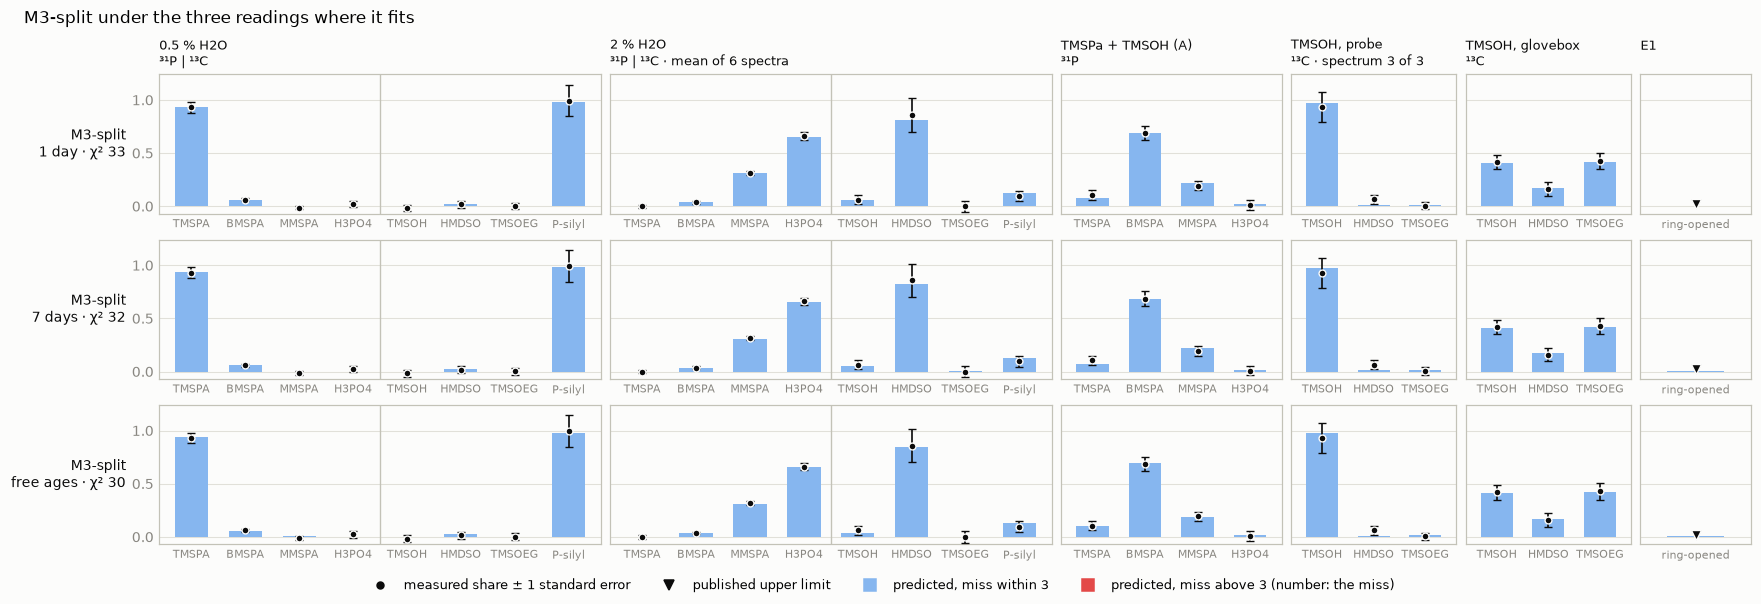

In [35]:
display(tables.format_rung_table(summary, barriers, MAIN, AGES, SEEN).rename_axis('reading', axis=1))
fit_plots.plot_compositions(dict(fitted(MAIN, scenario) for scenario in FITTING), PANELS, title=f'{MAIN} under the three readings where it fits');

**Result**

- **The three fits cannot be told apart, by eye or by χ²:** 32.7, 32.4 and 30.4 on 77 values. The bars are the same.
- **The worst miss is not a composition.** It is a "no change" value: TMSPA in the fourth spectrum of the 2 % tube (1.93). This is scatter among the six spectra, which no model can remove.
- **The same under every reading:** ΔG‡(R8) = 1.29 eV, ΔG‡(R4) = 1.24 eV, ΔG‡(R2) = 0.96–1.05 eV, ΔG‡(R3) = 0.98–1.07 eV.
- **Different under every reading:** ΔG‡(R1) = 1.31, 1.67 and 1.09 eV; ΔG‡(R5) = 0.59, 0.55 and 0.90 eV.

--> Four barriers do not depend on the reading; two do. 3.2 puts them on a common scale.

### 3.2 Barriers on a ruler

- **The ruler:** the upper scales translate a barrier into a half-life with the reaction partner at 1 M. At 22 °C a half-life of one second is 0.76 eV and one of ten years is 1.26 eV; +0.06 eV makes a reaction 10 times slower.
- **Table:** the range of ΔG‡ over the accepted sets. These are all the parameter sets met within Δχ² = 3.84 of the fit when one parameter at a time is moved away from its best value (§5.2).
- **Figure:** dot: best fit. Bar: the range of the table.

ΔG‡ over the accepted sets (eV),1 day,7 days,free ages
reaction,,,
R1 · first hydrolysis,1.20–1.61,1.23–1.67,1.08–1.58
R2 · second hydrolysis,0.93–0.98,0.96–1.03,0.94–1.08
R3 · third hydrolysis,0.95–1.00,0.98–1.05,0.96–1.10
R5 · first transfer,0.43–0.73,0.48–0.70,0.51–0.94
R4 · condensation,1.22–1.24,1.23–1.26,1.23–1.24
R8 · solvent attack,1.29–1.30,1.29–1.29,1.28–1.30


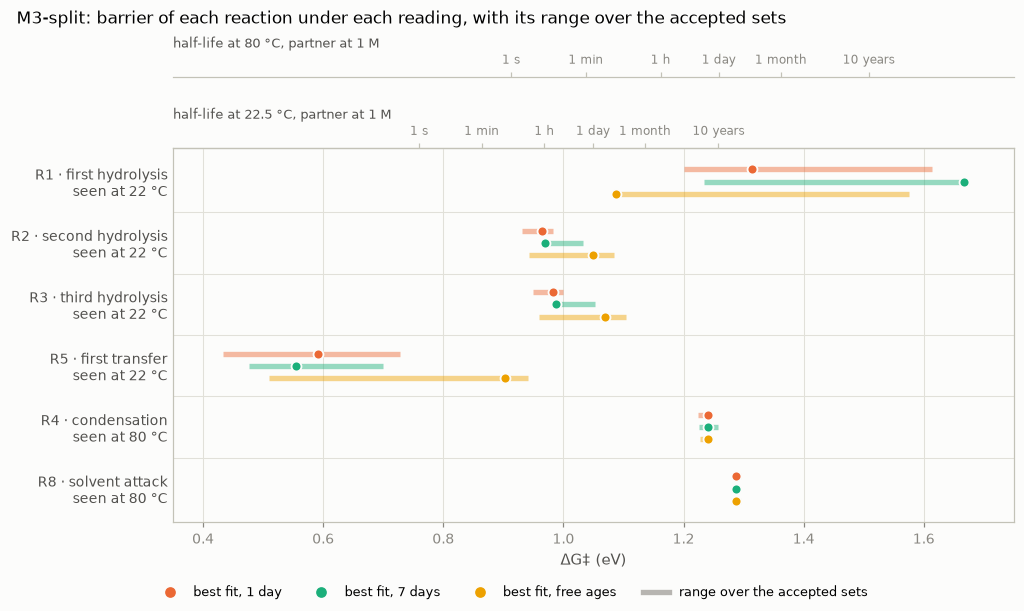

In [36]:
fit_plots.plot_barrier_ruler(barriers, bands, structure=MAIN, scenarios=FITTING, title=f'{MAIN}: barrier of each reaction under each reading, with its range over the accepted sets');
band = of_main(bands)
band = band.assign(barrier=[f'{lo:.2f}–{hi:.2f}' for lo, hi in zip(band['dG‡ low'], band['dG‡ high'])],
                   energy=[f'{lo:+.2f} to {hi:+.2f}' for lo, hi in zip(band['dG_rxn low'], band['dG_rxn high'])])
by_age(band.pivot(index='reaction', columns='scenario', values='barrier')).loc[list(SEEN)].rename(index=fit_plots.REACTION_LABELS).rename_axis(columns='ΔG‡ over the accepted sets (eV)')

**Result**

- **Narrow under every reading:** solvent attack 1.28–1.30 eV, condensation 1.22–1.26 eV, R2 0.93–1.08 eV, R3 0.95–1.10 eV.
- **Wide:** R1 spans 1.20–1.61 eV (1 day), 1.23–1.67 eV (7 days) and 1.08–1.58 eV (free ages). Transfer spans 0.43–0.73, 0.48–0.70 and 0.51–0.94 eV.
- **On the ruler (partner at 1 M):**
  - equal ages: R1 has a half-life of about a hundred years (1 day) or far longer (7 days), transfer one of about a millisecond;
  - free ages: R1 has a half-life of days, transfer one of minutes.
- **These are two different mechanisms** (3.4).

--> Before asking why, 3.3 shows what happened to the energies.

### 3.3 Reaction energies

- **Table and figure:** the computed ΔG_rxn of R1–R4 with its standard error, the fitted value under each reading, and the shift counted in standard errors.

computed (eV)                  fitted ΔG_rxn (eV)                   \
                ΔG_rxn ± standard error              1 day 7 days free ages   
reaction                                                                      
R1               -0.47             0.26              -0.05  -0.05     -0.04   
R2               -0.16             0.25               0.03   0.04      0.05   
R3               -0.18             0.24               0.07   0.07      0.09   
R4                0.10             0.34              -0.14  -0.15     -0.18   

         shift (standard errors)                   
                           1 day 7 days free ages  
reaction                                           
R1                          1.61   1.63      1.64  
R2                          0.78   0.79      0.84  
R3                          1.02   1.04      1.10  
R4                         -0.71  -0.73     -0.83

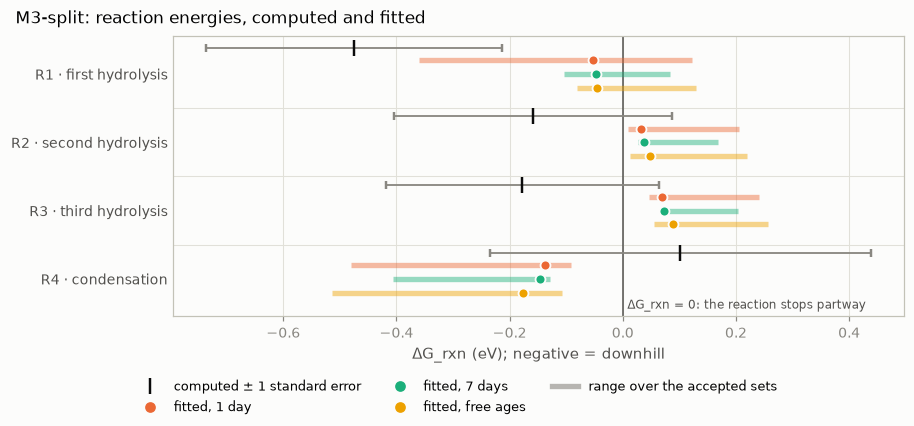

In [37]:
main = of_main(barriers)
computed = barriers[(barriers['structure'] == 'M1') & (barriers['scenario'] == 'middle')].set_index('reaction')['dG_rxn_eV']   # M1 keeps the computed energies
pulls = of_main(residuals[residuals['kind'] == 'prior'])
pulls = pulls.assign(reaction=pulls['quantity'].str.extract(r'\((R\d)\)')[0])
sigma = pulls.groupby('reaction')['sigma'].first()
display(pd.concat({'computed (eV)': pd.DataFrame({'ΔG_rxn': computed, '± standard error': sigma}),
                   'fitted ΔG_rxn (eV)': by_age(main.pivot(index='reaction', columns='scenario', values='dG_rxn_eV')),
                   'shift (standard errors)': by_age(pulls.pivot(index='reaction', columns='scenario', values='z'))}, axis=1).loc[['R1', 'R2', 'R3', 'R4']].round(2))
fit_plots.plot_energy_shifts(barriers, bands, structure=MAIN, computed=computed.to_dict(), sigma=sigma.to_dict(), scenarios=FITTING);

**Result**

- **The three readings agree** on each energy to 0.04 eV. In the first fit they were up to 0.2 eV apart (§4.1).
- **R2 and R3 move up to just above zero:** R2 from −0.16 to +0.03…+0.05 eV, R3 from −0.18 to +0.07…+0.09 eV. A reaction with ΔG_rxn near zero stops partway. This gives the resting composition of the 2 % tube (fact C).
- **R1 moves most:** from −0.47 to −0.05 eV.
- **R4 moves down:** from +0.10 to −0.14…−0.18 eV. Condensation is downhill, which is what the ¹³C of the 2 % tube shows (fact E: 86 % HMDSO). Over the accepted sets it lies between −0.51 and −0.09 eV: the computed value is excluded.
- **No shift is larger than 1.7 standard errors.** The fit uses the room that the uncertainty of the computed energies leaves.
- **Not moved:** R5–R7 follow from R1–R4 through the closed cycles. R8 and R9 keep their computed values.

--> The energies explain where the 2 % tube stops. 3.4 turns to the two barriers that change with the reading.

### 3.4 Two ways to consume TMSPA

- **Question:** fact B says TMSPA is still there with 0.5 % water and gone with 2 %. Four times more water makes hydrolysis four times faster, which is not enough. How does a fit serve both tubes?
- **Table:** hours from mixing until half of the TMSPA is gone.
- **Figure:** the TMSPA share of the two water tubes from the moment of mixing, for the best fit under each reading. The dots are the measured shares, placed at the age the reading gives the tube.

hours from mixing until half of the TMSPA is gone,1 day,7 days,free ages
sample,,,
0.5 % H2O,50.0,196.0,147.0
2 % H2O,14.0,50.0,34.0


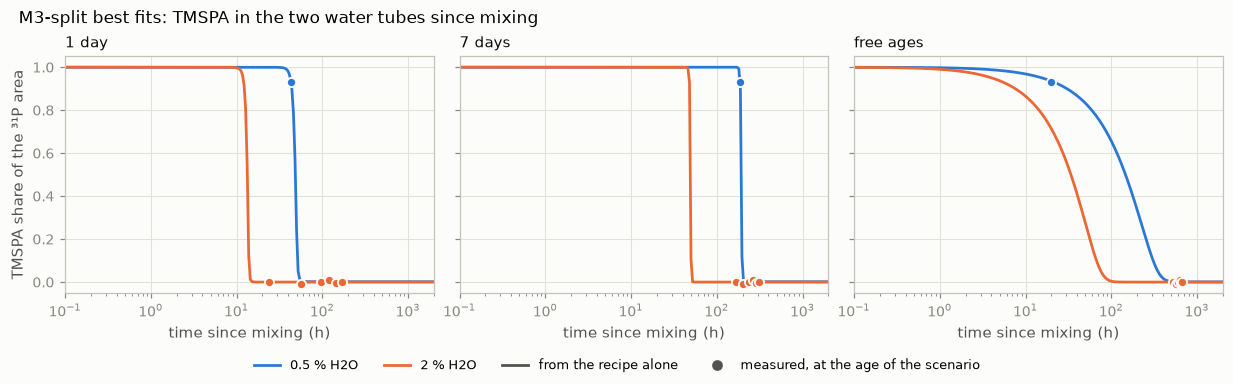

In [38]:
fit_plots.plot_sample_trajectories(trajectories, structure=MAIN, scenarios=FITTING, labels=fit_plots.AGE_LABELS, with_trace=False,
                                   title=f'{MAIN} best fits: TMSPA in the two water tubes since mixing');
model = of_main(trajectories[trajectories['kind'] == 'model'])
halved = lambda level: by_age(model[(model['TMSOH at mixing (M)'] == level) & (model['TMSPA'] < 0.5)].groupby(['sample', 'scenario'])['t_h'].min().unstack('scenario')).round(0)
halved(0.0).rename_axis(columns='hours from mixing until half of the TMSPA is gone')

**Result**

- **Equal ages (1 day, 7 days): a waiting time, then a cliff.**
  - R1 is almost closed. TMSPA is consumed by TMSOH through transfer, and every BMSPA and MMSPA that hydrolyses gives TMSOH back, so TMSOH multiplies.
  - Nothing is visible for hours, then TMSPA is gone within about one. In the 1-day fit: after 14 h with 2 % water and 50 h with 0.5 %. In the 7-day fit: after 50 h and 196 h.
  - The 0.5 % tube is then read 7 h (1-day fit) or 10 h (7-day fit) before its own cliff.
- **Free ages: ordinary kinetics.** R1 at 1.09 eV consumes TMSPA smoothly: half is gone after 34 h with 2 % water and 147 h with 0.5 %, four times slower for four times less water. The fit reads the 0.5 % tube 20 h after mixing (age at the 1 h limit) and the 2 % tube 22 days after mixing.
- **This is why R1 and R5 change with the reading.** The cliff needs R1 closed and transfer fast. The smooth decay needs R1 near 1.1 eV and a slower transfer.

--> Two different mechanisms fit the same 73 values. The data cannot choose a reading. §4 looks for something that can.

## 4. Which reading? Tests that could choose

**What this part delivers:** each reading against what its fit did not use.

| Step | Test | What it could show |
|---|---|---|
| 4.1 | the new ¹³C spectra | a silyl split that only one reading reproduces |
| 4.2 | a trace of TMSOH at mixing | a fit that needs a perfectly pure start |
| 4.3 | the tube "TMSPa alone" | a fit that cannot follow a tube in time |
| 4.4 | tube B, a later spectrum of tube A, the paper | a prediction that is off |
| 4.5 | verdict | every reading against every test |

### 4.1 Did the new ¹³C spectra choose?

- **Why they could:** the parameter sets of the first fit predict different silyl splits for the 2 % tube. Put on the new data without refitting, the 1-day set misses the TMSOH share by 4.4 standard errors (0.25 predicted, 0.06 measured) and the 7-day set by 12.6 (0.60 predicted); the free-age set still fits (worst miss 1.9). These three evaluations were made outside the result files (2026-10-07).
- **First table:** the silyl split of the 2 % tube, measured and predicted by the second fit. **Second table:** M3-split of the first and of the second fit side by side.

In [39]:
silyl = of_main(residuals[(residuals['sample'] == '2 % H2O') & (residuals['kind'] == 'mean')])
silyl = silyl[silyl['quantity'].str.contains('TMSOH|HMDSO|P-silyl')].assign(window=lambda d: d['quantity'].str.split(' ').str[0])
display(pd.concat({'measured': silyl.groupby('window', sort=False)[['measured', 'sigma']].first().rename(columns={'measured': 'share', 'sigma': '± standard error'}),
                   'predicted by the second fit': by_age(silyl.pivot_table(index='window', columns='scenario', values='predicted', sort=False))}, axis=1).round(2)
        .rename_axis('2 % tube, ¹³C'))
both = pd.concat({'first fit': pd.read_csv(FIRST / 'fits_barriers.csv'), 'second fit': barriers}, names=['fit']).reset_index('fit')
both = of_main(both).assign(reading=lambda d: d['scenario'].map(AGES))
order = [(AGES[scenario], fit) for scenario in FITTING for fit in ('first fit', 'second fit')]
side = lambda column, reactions: both.pivot(index='reaction', columns=['reading', 'fit'], values=column).loc[list(reactions), order]
pd.concat({'ΔG‡ (eV)': side('dG_barrier_eV', SEEN), 'ΔG_rxn (eV)': side('dG_rxn_eV', ('R1', 'R2', 'R3', 'R4'))}).round(2)

measured                  predicted by the second fit         \
                 share ± standard error                       1 day 7 days   
2 % tube, ¹³C                                                                
TMSOH             0.06             0.04                        0.06   0.05   
HMDSO             0.86             0.16                        0.81   0.82   
P-silyl           0.10             0.05                        0.13   0.13   

                         
              free ages  
2 % tube, ¹³C            
TMSOH              0.03  
HMDSO              0.84  
P-silyl            0.13

reading                  1 day               7 days            free ages  \
fit                  first fit second fit first fit second fit first fit   
            reaction                                                       
ΔG‡ (eV)    R1            1.45       1.31      1.39       1.67      1.09   
            R2            0.95       0.96      1.01       0.97      1.04   
            R3            0.97       0.98      1.03       0.99      1.06   
            R5            0.58       0.59      0.61       0.55      0.89   
            R4            1.24       1.24      1.24       1.24      1.24   
            R8            1.29       1.29      1.29       1.29      1.29   
ΔG_rxn (eV) R1           -0.09      -0.05     -0.12      -0.05     -0.04   
            R2           -0.01       0.03     -0.04       0.04      0.05   
            R3            0.03       0.07      0.01       0.07      0.09   
            R4           -0.06      -0.14      0.01      -0.15     -0.18   

reading                          
fit                  second fit  
            reaction             
ΔG‡ (eV)    R1             1.09  
            R2             1.05  
            R3             1.07  
            R5             0.90  
            R4             1.24  
            R8             1.29  
ΔG_rxn (eV) R1            -0.04  
            R2             0.05  
            R3             0.09  
            R4            -0.18

**Result**

- **No.** Fitted again with the ¹³C shares, M3-split fits under the same three readings (χ² 32.7, 32.4 and 30.4, worst miss 1.93). All three now give the silyl split of the 2 % tube: HMDSO 0.81–0.84 (measured 0.86 ± 0.16), TMSOH 0.03–0.06 (measured 0.06 ± 0.04).
- **What the ¹³C spectra contradicted** were the equal-age parameter sets of the first fit, not the equal-age readings.
- **What they changed:**
  - the energy of condensation: ΔG_rxn(R4) is −0.14 to −0.18 eV under every reading (first fit: −0.18 to +0.01 eV);
  - the equal-age barriers, which moved inside their open ranges: ΔG‡(R1) from 1.45 to 1.31 eV at 1 day and from 1.39 to 1.67 eV at 7 days;
  - nothing in the free-age fit (ΔG‡(R1) 1.09 eV, ΔG‡(R5) 0.89 → 0.90 eV).

--> The spectra that were expected to choose did not. 4.2 changes an assumption instead.

### 4.2 A trace of TMSOH at mixing

- **What was assumed:** every tube starts from its recipe alone, with no TMSOH at mixing.
- **Why doubt it:** the first spectrum of "TMSPa alone" already shows 12 ± 5 % BMSPA, and the 0.5 % tube 6 %. Each hydrolysed phosphate has released a silyl group. No reagent is pure to 1 µM.
- **Test 1:** each fit is kept as it is and TMSOH is added at mixing to the two water tubes, from 1 nM to 1 mM.
- **Test 2:** the fit is made again with 1 µM and with 1 mM in place.
- **First:** the time to the cliff with 1 µM of TMSOH at mixing, and the trajectories of 3.4 with that trace as dashed lines.
- **Then:** χ² with the parameters unchanged, the fits made again, and the worst miss against the size of the trace (line: parameters unchanged; open circle: fitted again).

with 1 µM TMSOH: hours until half of the TMSPA is gone,1 day,7 days,free ages
sample,,,
0.5 % H2O,41.0,42.0,147.0
2 % H2O,11.0,12.0,34.0


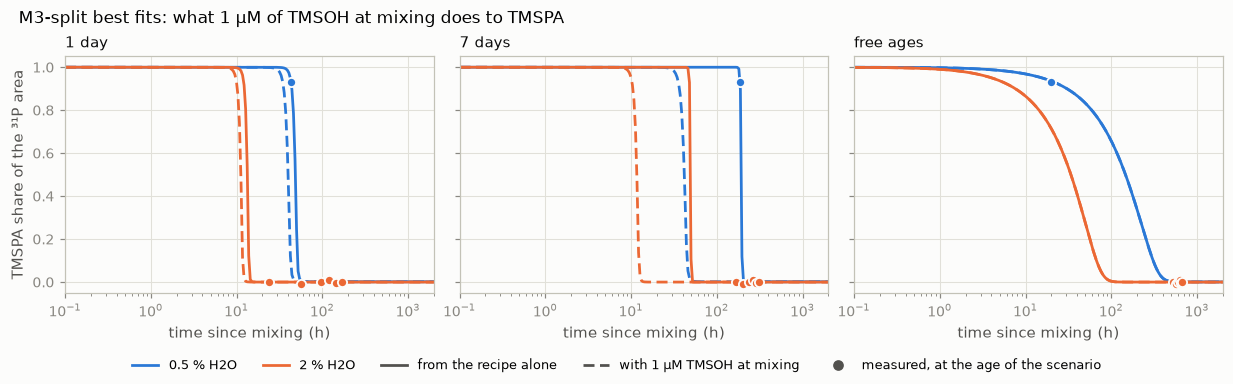

In [40]:
fit_plots.plot_sample_trajectories(trajectories, structure=MAIN, scenarios=FITTING, labels=fit_plots.AGE_LABELS,
                                   title=f'{MAIN} best fits: what 1 µM of TMSOH at mixing does to TMSPA');
display(halved(1e-6).rename_axis(columns='with 1 µM TMSOH: hours until half of the TMSPA is gone'))

"χ², parameters unchanged",1 day,7 days,free ages
TMSOH at mixing,,,
none,32.7,32.4,30.4
1 nM,32.7,1449.1,30.4
100 nM,42.6,1449.1,30.4
1 µM,2128.4,1449.1,30.4
10 µM,1458.5,1449.1,30.4
100 µM,1448.7,1449.1,30.4
1 mM,1448.5,1449.6,30.6


χ²  worst miss   fits  ΔG‡ R1  ΔG‡ R2  ΔG‡ R3  \
fitted again with reading                                                       
1 µM              1 day      32.74        1.93   True    1.67    0.97    0.99   
                  7 days     34.00        1.93   True    1.55    1.00    1.02   
                  free ages  30.37        1.93   True    1.09    1.05    1.07   
1 mM              1 day      53.97        3.77  False    1.42    0.98    1.00   
                  7 days     39.75        2.50   True    1.39    1.02    1.04   
                  free ages  30.42        1.93   True    1.09    1.05    1.07   

                             ΔG‡ R5  ΔG‡ R4  ΔG‡ R8  
fitted again with reading                            
1 µM              1 day        0.59    1.24    1.29  
                  7 days       0.66    1.24    1.29  
                  free ages    0.90    1.24    1.29  
1 mM              1 day        0.78    1.24    1.29  
                  7 days       0.89    1.24    1.29  
                  free ages    0.90    1.24    1.29

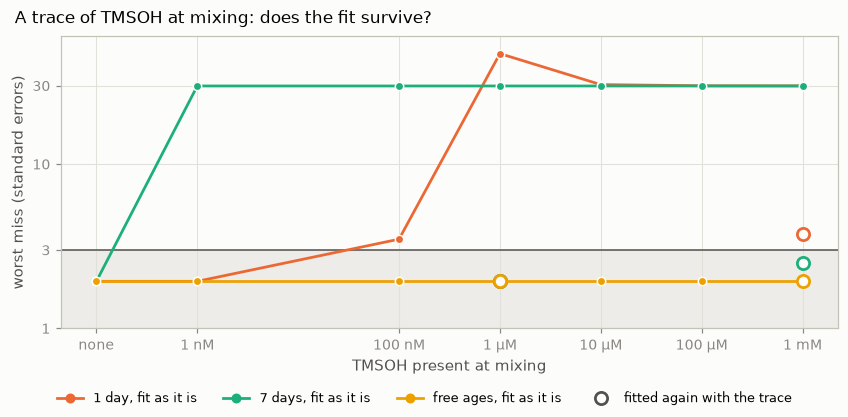

In [41]:
scan = of_main(traces.assign(structure=MAIN, trace=traces['TMSOH at mixing (M)'].map(show_M)))
fit_plots.plot_trace_scan(scan, scenarios=FITTING);
display(by_age(scan[scan['parameters'] == 'as fitted without it'].pivot_table(index='trace', columns='scenario', values='chi2', sort=False)).round(1)
        .rename_axis(index='TMSOH at mixing', columns='χ², parameters unchanged'))
refits = scan[scan['parameters'] == 'fitted again'].assign(reading=lambda d: d['scenario'].map(AGES))
refits.set_index(['trace', 'reading'])[['chi2', 'max |z|', 'fits'] + BARRIERS].round(2).rename(columns={'chi2': 'χ²', 'max |z|': 'worst miss'}).rename(
    columns=lambda c: c.replace('dG‡', 'ΔG‡')).rename_axis(index=['fitted again with', 'reading'])

**Result**

- **The cliff is timed by what starts it.** With 1 µM of TMSOH the cliff of the 0.5 % tube comes after 41–42 h, where the 1-day fit had it at 50 h and the 7-day fit at 196 h. That is before the spectrum that shows 93 % TMSPA.
- **Parameters unchanged:** the 7-day fit breaks with 1 nM (χ² 32 → 1 449). The 1-day fit breaks with 100 nM (worst miss 3.5) and is far off with 1 µM (χ² 2 128, worst miss 47).
- **The 7-day fit also depends on the solver:** its χ² is 32.4 at the tolerance of the report and 47.5 at the looser tolerance of the search (A.3).
- **Fitted again, an equal age can still fit, with other barriers.**
  - With 1 µM both equal ages fit (χ² 32.7 and 34.0).
  - With 1 mM the 7-day reading fits (χ² 39.8, worst miss 2.5) and the 1-day reading does not (worst miss 3.8).
  - Over the equal-age fits that pass, ΔG‡(R1) lies anywhere from 1.31 to 1.67 eV and ΔG‡(R5) from 0.55 to 0.89 eV.
- **The free-age fit does not react to a trace:** χ² 30.4 from none to 0.1 mM and 30.6 with 1 mM. Fitted again it is 30.4, and no barrier moves by more than 0.003 eV.

**Verdict**

- **Holds:** ΔG‡ of R8, R4, R2 and R3, the same with or without a trace.
- **Does not hold:** ΔG‡ of R1 and R5 at equal ages. They are set by the assumed trace, not by the data.

--> The equal-age fits rest on a start that is pure to better than 1 µM. 4.3 tests the free-age fit.

### 4.3 The tube that was not fitted: TMSPa alone

- **The tube:** TMSPA with no water added, two spectra 243 h apart. It goes from 81 % TMSPA and 12 % BMSPA to 23 % TMSPA and 69 % BMSPA, and stops there: MMSPA stays at 4–5 %. It is the only tube seen moving at room temperature.
- **Test:** the fitted barriers are kept. The tube starts from its first spectrum. Its water content is unknown, so it is the one number adjusted.
- **What the first spectrum leaves open:** where the silyl groups already released are. Three starts are tried: absent, present as TMSOH, present as HMDSO.
- **Table:** the water this takes and the worst miss, for each start. **Figure:** the shares after 243 h, measured and predicted under each reading with the most favourable start.

water (mM)              worst miss  \
silyl groups already released, present as       none TMSOH  HMDSO       none   
reading   parameters                                                           
1 day     the fit                               37.8  13.7   37.8        0.8   
          fitted with TMSOH 1uM at mixing       37.7  13.6   37.8        0.8   
          fitted with TMSOH 1mM at mixing       37.3  12.4   36.6        0.8   
7 days    the fit                               37.8  13.7   37.8        0.8   
          fitted with TMSOH 1uM at mixing       38.2  13.7   38.1        0.8   
          fitted with TMSOH 1mM at mixing      141.6  30.7  126.5        6.6   
free ages the fit                              173.3  53.4  169.8        5.8   
          fitted with TMSOH 1uM at mixing      173.3  53.4  169.8        5.8   
          fitted with TMSOH 1mM at mixing      188.7  57.2  185.2        5.8   

                                                       
silyl groups already released, present as TMSOH HMDSO  
reading   parameters                                   
1 day     the fit                           0.8   0.8  
          fitted with TMSOH 1uM at mixing   0.8   0.8  
          fitted with TMSOH 1mM at mixing   0.8   0.8  
7 days    the fit                           0.8   0.8  
          fitted with TMSOH 1uM at mixing   0.8   0.8  
          fitted with TMSOH 1mM at mixing   3.5   5.9  
free ages the fit                           4.1   5.6  
          fitted with TMSOH 1uM at mixing   4.1   5.6  
          fitted with TMSOH 1mM at mixing   4.2   5.7

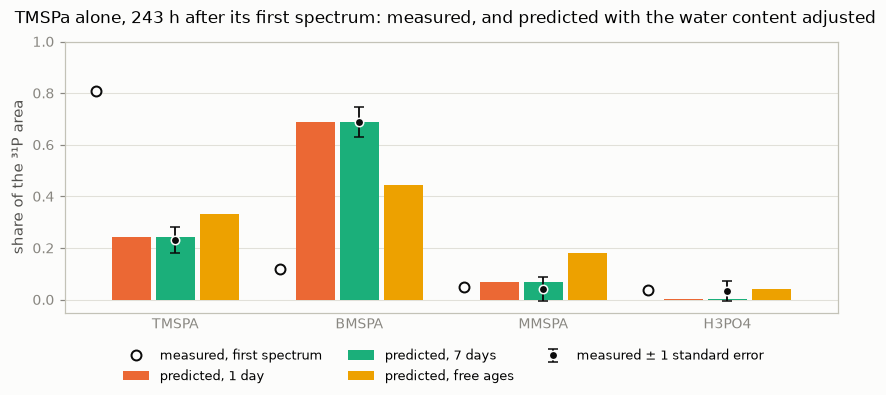

In [42]:
first, late = measured_shares('TMSPa alone', 0), measured_shares('TMSPa alone', 1)
kept_fit = of_main(alone[alone['parameters'] == 'the fit'])
favourable = kept_fit.loc[kept_fit.groupby('scenario')['chi2'].idxmin()].set_index('scenario')
fit_plots.plot_tube_check(late, {scenario: {w: favourable.loc[scenario, f'{w} predicted'] for w in late.index} for scenario in FITTING}, start=first,
                          title='TMSPa alone, 243 h after its first spectrum: measured, and predicted with the water content adjusted');
checked = of_main(alone).assign(reading=lambda d: pd.Categorical(d['scenario'].map(AGES), [AGES[s] for s in FITTING]))
(checked.set_index(['reading', 'parameters', 'co-products'])[['water_mM', 'max |z|']].rename(columns={'water_mM': 'water (mM)', 'max |z|': 'worst miss'})
 .unstack('co-products', sort=False).sort_index(level='reading', sort_remaining=False).round(1)
 .rename_axis(index=['reading', 'parameters'], columns=[None, 'silyl groups already released, present as']))

**Result**

- **The equal-age fits reproduce the tube** (worst miss 0.8) with 14–38 mM of water (210–590 ppm). They need little water because transfer passes the silyl groups on: through R1 and then R5, one water molecule takes a silyl group off two TMSPA.
- **The free-age fit cannot, at any water content** (worst miss 4.1–5.8, with 53–173 mM of water). It predicts 35–45 % BMSPA where 69 % is measured, and 18–24 % MMSPA where 4 % is measured. Its three hydrolysis barriers are too close (1.09, 1.05 and 1.07 eV) for the phosphate to rest at BMSPA.
- **A trace does not rescue either side.** With the parameters fitted at 1 mM TMSOH the 7-day reading no longer reproduces the tube (worst miss 3.5–6.6), and the free-age fit stays at 4.2–5.8.
- **What a screening found** (see the plan; not in these result files): with the transfer barrier held at 0.70–0.80 eV the free-age fit reproduces this tube (χ² 3 on its 8 values), at a cost of 3 to 5 in χ² on the fitted tubes.

--> The tube that carries the rate information is outside the fit, and it contradicts the only reading that survives a trace. 4.4 looks at the remaining checks.

### 4.4 Other spectra the fit did not use, and the paper

- **Tube B:** same recipe as tube A, one ³¹P spectrum of 16 scans. **Tube A, ¹³C:** recorded 234 h after the ³¹P spectrum that was fitted.
- **The paper:** statements of Gogoi 2024 about TMSPA + TMSOH (E4) and about the water series (W1 with 1 vol% water, W5 with 5 vol%).
- **Table:** the paper statements against the predictions. **Figure:** the two spectra, predicted under each reading.

predicted                                                                                                                                1 day  \
paper statement                                                              time since mixing                                                   
E4    TMSPA conversion ≥ 0.95                                                24 h (assumed)                                              0.923   
W1    reaction stops at BMSPA while most TMSPA remains unreacted (text only) 1 h                TMSPA 1.00, BMSPA 0.00, MMSPA 0.00, H3PO4 0.00   
                                                                             1 d                TMSPA 0.00, BMSPA 0.08, MMSPA 0.41, H3PO4 0.51   
                                                                             7 d                TMSPA 0.00, BMSPA 0.07, MMSPA 0.39, H3PO4 0.53   
W5    H3PO4 and a very weak MMSPA signal (Fig. 1c)                           1 h                TMSPA 1.00, BMSPA 0.00, MMSPA 0.00, H3PO4 0.00   
                                                                             1 d                TMSPA 0.00, BMSPA 0.01, MMSPA 0.22, H3PO4 0.77   
                                                                             7 d                TMSPA 0.00, BMSPA 0.01, MMSPA 0.22, H3PO4 0.77   

predicted                                                                                                                               7 days  \
paper statement                                                              time since mixing                                                   
E4    TMSPA conversion ≥ 0.95                                                24 h (assumed)                                              0.923   
W1    reaction stops at BMSPA while most TMSPA remains unreacted (text only) 1 h                TMSPA 1.00, BMSPA 0.00, MMSPA 0.00, H3PO4 0.00   
                                                                             1 d                TMSPA 1.00, BMSPA 0.00, MMSPA 0.00, H3PO4 0.00   
                                                                             7 d                TMSPA 0.00, BMSPA 0.07, MMSPA 0.39, H3PO4 0.53   
W5    H3PO4 and a very weak MMSPA signal (Fig. 1c)                           1 h                TMSPA 1.00, BMSPA 0.00, MMSPA 0.00, H3PO4 0.00   
                                                                             1 d                TMSPA 0.00, BMSPA 0.02, MMSPA 0.22, H3PO4 0.77   
                                                                             7 d                TMSPA 0.00, BMSPA 0.02, MMSPA 0.22, H3PO4 0.77   

predicted                                                                                                                            free ages  
paper statement                                                              time since mixing                                                  
E4    TMSPA conversion ≥ 0.95                                                24 h (assumed)                                              0.926  
W1    reaction stops at BMSPA while most TMSPA remains unreacted (text only) 1 h                TMSPA 0.99, BMSPA 0.01, MMSPA 0.00, H3PO4 0.00  
                                                                             1 d                TMSPA 0.76, BMSPA 0.19, MMSPA 0.05, H3PO4 0.00  
                                                                             7 d                TMSPA 0.00, BMSPA 0.13, MMSPA 0.47, H3PO4 0.41  
W5    H3PO4 and a very weak MMSPA signal (Fig. 1c)                           1 h                TMSPA 0.96, BMSPA 0.04, MMSPA 0.00, H3PO4 0.00  
                                                                             1 d                TMSPA 0.03, BMSPA 0.22, MMSPA 0.45, H3PO4 0.30  
                                                                             7 d                TMSPA 0.00, BMSPA 0.01, MMSPA 0.22, H3PO4 0.77

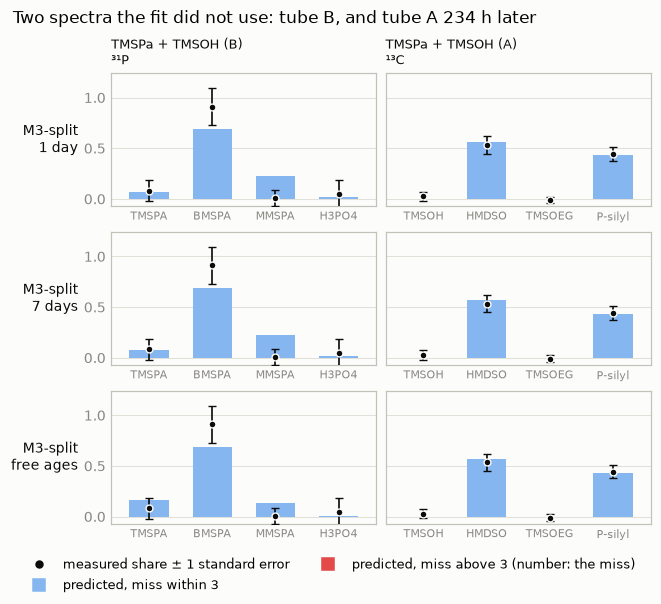

In [43]:
unused = pd.concat([hold_out, later])
fit_plots.plot_compositions({f'{MAIN}\n{AGES[scenario]}': unused[(unused['structure'] == MAIN) & (unused['scenario'] == scenario)] for scenario in FITTING},
                            ['TMSPa + TMSOH (B)', 'TMSPa + TMSOH (A)'], title='Two spectra the fit did not use: tube B, and tube A 234 h later');
by_age(of_main(paper).pivot_table(index=['observation', 'statement', 'age'], columns='scenario', values='predicted', aggfunc='first', sort=False)).rename_axis(
    index=['paper', 'statement', 'time since mixing'], columns='predicted')

**Result**

- **Tube B is not contradicted, and says little** (worst miss 2.8 at equal ages, 1.7 with free ages). The fits give it nearly the composition of tube A, with 14–22 % MMSPA where tube B shows 1 ± 8 %. Its errors reach 0.18.
- **The later ¹³C spectrum of tube A is predicted under every reading** (worst miss 0.6): HMDSO 0.57 against 0.54 ± 0.09, P-silyl 0.43 against 0.45 ± 0.07. In every fit tube A changes little after its first spectrum, so this one cannot choose.
- **Paper, TMSPA + TMSOH (E4):** predicted conversion 0.92–0.93, where "no TMSPA detectable" was read as at least 0.95. The lab's own tube A, same recipe, shows 0.90 ± 0.05.
- **Paper, 1 vol% water (W1):** "the reaction stops at BMSPA while most TMSPA remains unreacted". No fit stops there. Each agrees only while the reaction has not gone far (the 1-day fit up to 1 h, the other two up to 1 day) and predicts no TMSPA after a week.
- **Paper, 5 vol% water (W5):** "H₃PO₄ and a very weak MMSPA signal". Every fit ends at 77 % H₃PO₄ and 22 % MMSPA: the fitted energies stop this sample where they stop the 2 % tube.
- **The paper gives no time** between mixing and spectrum.

--> None of these separates the readings. 4.5 collects the verdict.

### 4.5 Verdict: every reading against every test

The picture of §0, in words:

| Reading | Fits the 73 values | A trace of TMSOH at mixing | TMSPa alone | Verdict |
|---|---|---|---|---|
| 1 h | no (13.4) | — | no (9.7) | out |
| 1 day | yes | breaks with 100 nM as it is; fitted again it fails with 1 mM (3.8) | yes (0.8) | needs a start pure to better than 1 µM |
| 7 days | yes | breaks with 1 nM as it is; fitted again it fits, with R1 and R5 moved by up to 0.28 and 0.34 eV | yes without a trace (0.8); no with the parameters fitted at 1 mM (3.5) | no single parameter set passes both tests |
| Free ages | yes | no effect at any level | no (4.1) | fails the only tube seen in time |

- **No reading passes every test.**
- **What follows** (§7): free ages become the base reading, because they are the only ones that survive a trace. "TMSPa alone" has to enter the fit, because it is what the free-age fit gets wrong.

--> The mechanism that consumes TMSPA stays open. §5 asks how firm the rest is.

## 5. How firm is the settled part?

**What this part delivers:** for each value that does not depend on the reading, whether it stays when something that was assumed is changed.

| Step | Question | What is changed |
|---|---|---|
| 5.1 | Does the search find a known answer? | the lab shares are replaced by shares made from known parameters |
| 5.2 | How wide is each value? | one parameter is moved away from its best value until the fit gets worse |
| 5.3 | Which tube decides each value? | one tube is left out |
| 5.4 | Equilibrium, or did the water run out? | part of the added water is made unavailable |
| 5.5 | Do the declared choices matter? | error floor, energy errors, heating times, barrier relation |
| 5.6 | Scorecard | every barrier against every test |

### 5.1 Does the search find a known answer?

- **Test:** shares are generated from a known parameter set with the lab design (same tubes, times and errors), noise is added, and the fit has to find the parameters again.
- **Cases:** A is M1-split (three noise draws). B is M3-split with ΔG_rxn of R2 and R3 moved by +0.12 and +0.17 eV (two noise draws).
- **Table:** χ² of the fit against χ² of the true parameters. **Figure:** per parameter, the 95 % interval of each case against the value that made the data.

,χ² of the fit,χ² of the true parameters,true values inside their interval,intervals
case,,,,
"A, seed 1",35.4,37.7,5,5
"A, seed 2",45.8,52.3,5,5
"A, seed 3",59.5,66.0,4,5
"B, seed 1",37.8,40.3,7,7
"B, seed 2",52.6,54.9,7,7


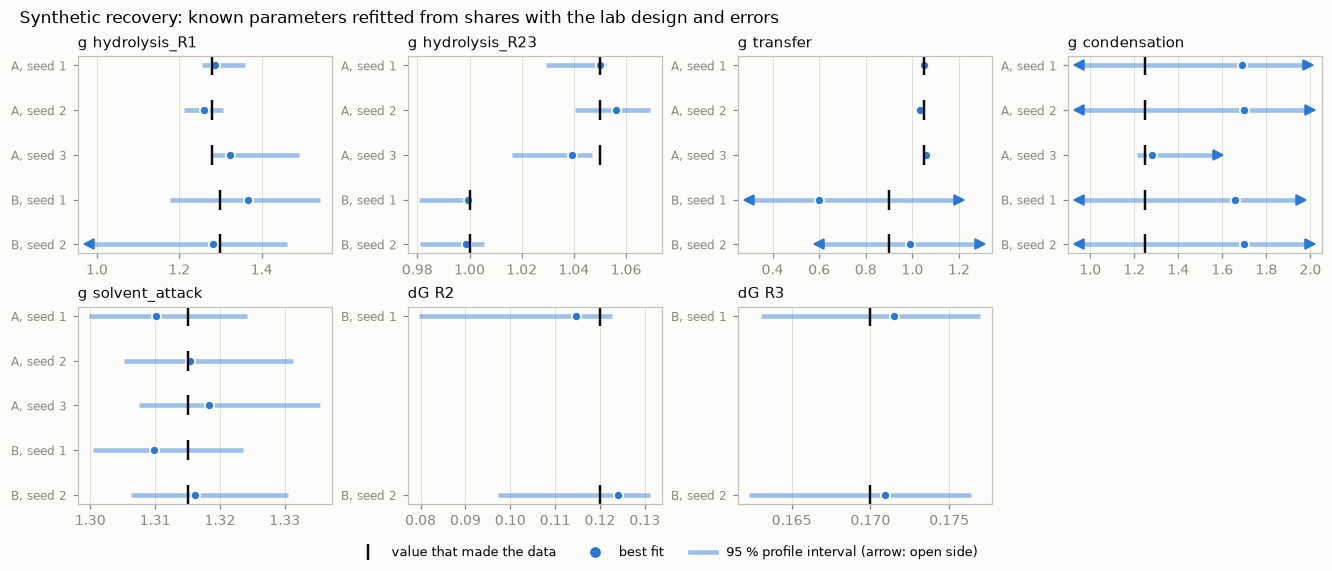

In [44]:
recovery = read('recovery_summary.csv')
display(recovery.groupby('case').agg(**{'χ² of the fit': ('chi2 fit', 'first'), 'χ² of the true parameters': ('chi2 truth', 'first'),
                                        'true values inside their interval': ('truth inside', 'sum'), 'intervals': ('truth inside', 'size')}).round(1))
fit_plots.plot_recovery(recovery);

**Result**

- **The search finds the optimum.** In all five cases the fit reaches a χ² below that of the true parameters.
- **The intervals are honest.** 28 of the 29 true values lie inside their 95 % interval. The one outside is the R2–R3 barrier in one case A, by 0.003 eV.
- **Determined when the model is right:** the solvent-attack barrier (±0.015 eV every time), the R2–R3 barrier (±0.015 eV), and in case B the energies of R2 and R3 (±0.02 eV or better).
- **Not determined even when the model is right:** condensation (a lower limit at most), and in case B transfer (nothing) and R1 (±0.18 eV, or an upper limit only).

**Verdict:** the method works. A "not determined" for R1, transfer or condensation is a property of the tubes that exist, not a failure of the fit.

--> The search can be trusted. The next tests are about the assumptions.

### 5.2 How wide is each value?

- **Test:** one parameter is moved away from its best value in steps, and all the others are fitted again at each step. The 95 % interval ends where χ² has risen by 3.84.
- **Table:** the intervals of the parameters as they are fitted: g, the intrinsic barrier of a family (eV), and dG, the shift of a reaction energy from its computed value (eV). A side that the data do not close is left open.
- **Per reaction:** the same information as ΔG‡ is the table and the bars of 3.2.

In [45]:
tables.format_interval_table(intervals, MAIN, scenarios=FITTING).rename(columns=AGES).rename_axis(f'{MAIN}: 95 % interval', axis=1)

M3-split: 95 % interval,1 day,7 days,free ages
dG R1,0.143–0.607,0.318–0.560,0.389–0.623
dG R2,0.150–0.367,0.189–0.329,0.170–0.400
dG R3,0.222–0.431,0.239–0.381,0.235–0.458
dG R4,≤ -0.189,≤ -0.219,≤ -0.202
g condensation,1.271–1.404,1.272–1.445,1.280–1.508
g hydrolysis_R1,≥ 1.158,not determined,≥ 1.012
g hydrolysis_R23,0.930–0.963,0.898–0.988,0.918–1.076
g solvent_attack,1.309–1.325,1.298–1.327,1.298–1.319
g transfer,≤ 0.832,≤ 0.854,≤ 1.060
log10 age 2 % H2O,—,—,≥ 0.94


**Result**

- **Closed under every reading:** solvent attack (g 1.30–1.33 eV), condensation (g 1.27–1.51 eV), the R2–R3 barrier (g 0.90–1.08 eV), and the shifts of R1, R2 and R3.
- **Open on one side:**
  - transfer has an upper limit only (g at most 0.83, 0.85 and 1.06 eV);
  - the shift of R4 has an upper limit only (at most −0.19 eV: condensation is downhill by at least 0.09 eV);
  - R1 has a lower limit at 1 day (g at least 1.16 eV) and with free ages (at least 1.01 eV), and nothing at 7 days.
- **The ¹³C spectra did not narrow R1.** With free ages its interval was closed in the first fit (g 1.00–1.18 eV). Now a second branch with a higher R1 fits as well, so the range of ΔG‡(R1) runs up to 1.58 eV (first fit: 1.08–1.14 eV).
- **Age:** with free ages the 2 % tube is at least 9 h old at its first spectrum. There is no upper limit inside 30 days.
- **Every interval is conditional** on its reading and on tubes that start from the recipe alone (4.2).
- **Solver tolerance:** two intervals repeated at a tighter tolerance move by at most 0.013 eV (A.5).

--> The intervals say how well a value is held. 5.3 asks which tube holds it.

### 5.3 Which tube decides each value?

- **Test:** the fit of M3-split is repeated without each tube in turn.
- **Table:** χ² and the worst miss without the tube. **Figures:** how far ΔG‡ of each reaction moves (in meV) when a tube is left out, at 1 day and with free ages.

χ² without the tube                   \
reading                         1 day 7 days free ages   
left out                                                 
0.5 % H2O                        31.1   31.1      28.7   
2 % H2O                           2.4    2.3       2.5   
E1                               32.7   32.4      30.4   
TMSOH, glovebox                  30.1   29.9      27.9   
TMSOH, probe                     29.5   29.5      27.2   
TMSPa + TMSOH (A)                29.2   29.9      27.8   

                  worst miss without the tube                   
reading                                 1 day 7 days free ages  
left out                                                        
0.5 % H2O                                1.93   1.93      1.93  
2 % H2O                                  0.78   0.79      0.79  
E1                                       1.93   1.93      1.93  
TMSOH, glovebox                          1.93   1.93      1.93  
TMSOH, probe                             1.93   1.93      1.93  
TMSPa + TMSOH (A)                        1.93   1.93      1.93

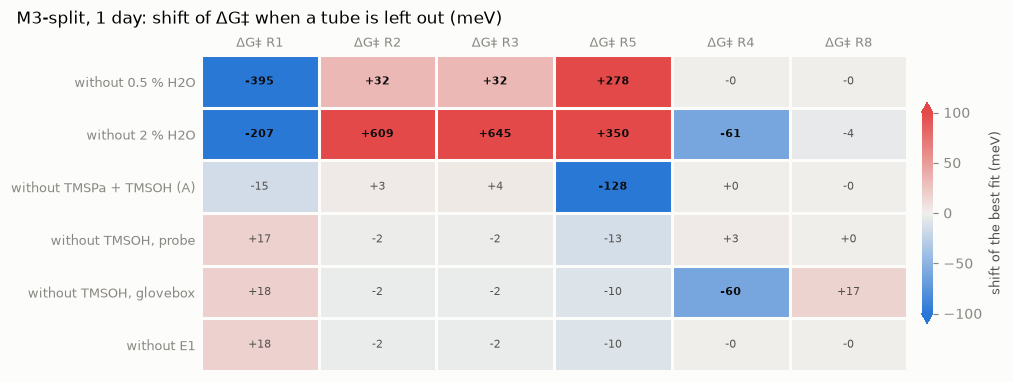

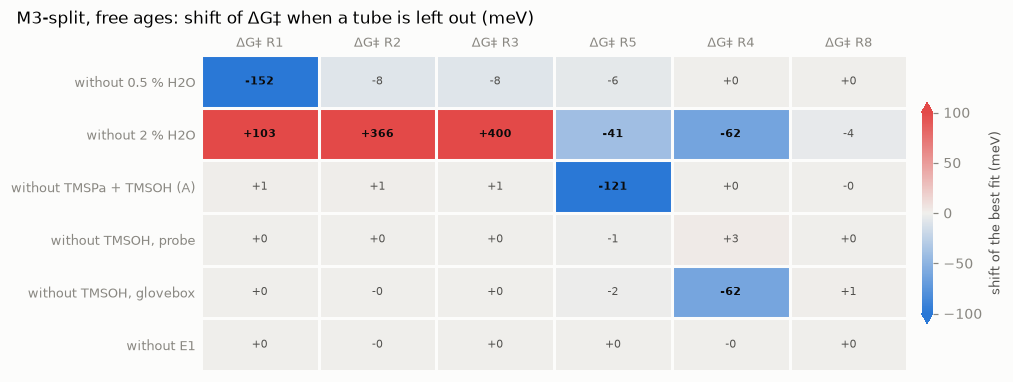

In [46]:
loo = loo[loo['structure'] == MAIN]
best = barriers[barriers['structure'] == MAIN].pivot(index='scenario', columns='reaction', values='dG_barrier_eV')
for scenario in ('middle', 'free'):
    fit_plots.plot_influence(loo[loo['scenario'] == scenario], {c: best.loc[scenario, c.split(' ')[1]] for c in BARRIERS}, columns=BARRIERS,
                             title=f'{MAIN}, {AGES[scenario]}: shift of ΔG‡ when a tube is left out (meV)')
pd.concat({'χ² without the tube': by_age(loo.pivot(index='left out', columns='scenario', values='chi2')).round(1),
           'worst miss without the tube': by_age(loo.pivot(index='left out', columns='scenario', values='max |z|')).round(2)}, axis=1)

**Result**

- **The 2 % water tube carries χ², the barriers of R2–R3 and the energy shifts.** Without it χ² falls from 30–33 to 2.3–2.5, ΔG‡(R2) runs up to 1.42–1.57 eV, and the energies of R2, R3 and R4 go back to within 0.10 eV of their computed values.
- **With free ages R1 rests on the 0.5 % tube.** Without it ΔG‡(R1) falls from 1.09 to 0.94 eV.
- **At equal ages R1 and transfer need both water tubes.** Without the 0.5 % tube the 1-day fit moves ΔG‡(R1) from 1.31 to 0.92 eV and ΔG‡(R5) from 0.59 to 0.87 eV: the waiting time of 3.4 is there because of this one spectrum.
- **Tube A sets transfer and the energy of R1.** Without it ΔG‡(R5) falls by 0.12–0.13 eV (free ages, 1 day), and the shift of R1 falls from +0.43 to between +0.13 and +0.24 eV.
- **Condensation needs two tubes.** ΔG‡(R4) falls from 1.24 to 1.18–1.19 eV without the glovebox tube, and the same without the 2 % tube.
- **The probe tube and E1 move nothing** (at most 0.02 eV). What they say about solvent attack is also said by the glovebox tube.
- **Every fit without one tube still fits** (worst miss 1.93), so no tube contradicts the others.

**Verdict**

- **Solvent attack** is the only barrier that no single tube moves (at most 0.02 eV): two tubes check it independently.
- **R2–R3 and the energy shifts** rest on the 2 % tube alone. **R1** rests on the 0.5 % tube with free ages, and on both water tubes at equal ages.
- **Condensation** needs the glovebox tube and the 2 % tube together.

--> Each value has one or two tubes behind it. 5.4 turns to the second explanation of fact C.

### 5.4 Equilibrium, or did the water run out?

- **Question:** 3.3 explains the resting 2 % tube by its energies: R2 and R3 close to thermoneutral. There is a second explanation: part of the added water did not take part, and hydrolysis stopped when the available water was used up. No spectrum measures water.
- **Test:** one more parameter, the available fraction of the added water, is given to M3-split and to M1-split (which keeps the computed energies).
- **First table:** the fits with this parameter ("+W"), on the lab shares and on shares made by the other structure. **Second table:** barriers and energies of M3-split with all the water and with the fitted fraction, about a fifth.
- **Figure:** how χ² of M3-split changes along the available fraction.

χ²  worst miss   fits  \
reading   fitted     data                                           
1 day     M3-split+W lab                 30.78        1.93   True   
          M1-split+W lab                 92.72        7.04  False   
                     made by M3-split    67.19        6.76  False   
          M3-split   made by M1-split+W   5.70        1.44   True   
free ages M3-split+W lab                 29.15        1.93   True   
          M1-split+W lab                 90.98        7.06  False   
                     made by M3-split    67.82        6.85  False   
          M3-split   made by M1-split+W   4.87        1.45   True   

                                         water fraction  
reading   fitted     data                                
1 day     M3-split+W lab                           0.20  
          M1-split+W lab                           0.21  
                     made by M3-split              0.21  
          M3-split   made by M1-split+W             NaN  
free ages M3-split+W lab                           0.19  
          M1-split+W lab                           0.21  
                     made by M3-split              0.21  
          M3-split   made by M1-split+W             NaN

reading                      1 day                          free ages  \
water that took part all the water a fifth of the water all the water   
eV                                                                      
ΔG‡ R1                        1.31                 1.24          1.09   
ΔG‡ R2                        0.96                 1.09          1.05   
ΔG‡ R3                        0.98                 1.10          1.07   
ΔG‡ R5                        0.59                 0.51          0.90   
ΔG‡ R4                        1.24                 1.11          1.24   
ΔG‡ R8                        1.29                 1.28          1.29   
ΔG_rxn R1                    -0.05                -0.38         -0.04   
ΔG_rxn R2                     0.03                -0.29          0.05   
ΔG_rxn R3                     0.07                -0.26          0.09   
ΔG_rxn R4                    -0.14                 0.19         -0.18   

reading                                    
water that took part a fifth of the water  
eV                                         
ΔG‡ R1                               1.15  
ΔG‡ R2                               1.24  
ΔG‡ R3                               1.26  
ΔG‡ R5                               0.85  
ΔG‡ R4                               1.09  
ΔG‡ R8                               1.28  
ΔG_rxn R1                           -0.40  
ΔG_rxn R2                           -0.31  
ΔG_rxn R3                           -0.27  
ΔG_rxn R4                            0.18

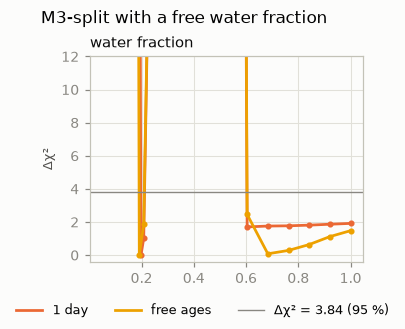

In [47]:
shown = {'chi2': 'χ²', 'max |z|': 'worst miss', 'within 3 SE': 'fits'}
same = same.assign(reading=same['scenario'].map(AGES))
display(same[same['question'] == 'equilibrium or exhausted water'].set_index(['reading', 'fitted', 'data'])[list(shown) + ['water fraction']].rename(columns=shown).round(2))
water = {scenario: load_fit_result(str(RESULTS / 'profiles' / f'{MAIN}+W__{scenario}.json'))['profile'] for scenario in ('middle', 'free')}
fit_plots.plot_profiles(water, ['water fraction'], title='M3-split with a free water fraction', labels=fit_plots.AGE_LABELS);
compare = {(AGES[scenario], label): {**{f'ΔG‡ {r}': fit['barriers'][r]['dG_barrier_eV'] for r in SEEN}, **{f'ΔG_rxn {r}': fit['barriers'][r]['dG_rxn_eV'] for r in ('R1', 'R2', 'R3', 'R4')}}
           for scenario in ('middle', 'free') for label, name in (('all the water', MAIN), ('a fifth of the water', f'{MAIN}+W'))
           for fit in [load_fit_result(str(RESULTS / 'fits' / f'{name}__{scenario}.json'))]}
pd.DataFrame(compare).round(2).rename_axis(index='eV', columns=['reading', 'water that took part'])

**Result**

- **Two separate ranges of the fraction fit:** about 0.19–0.21, and 0.60–1. Between them χ² is 100 or more. (In the first fit any fraction from 0.2 to 1 fitted.)
- **A fraction of 0.2 is the water the reaction used.** 0.2 × 1 052 mM ≈ 210 mM, which is about what the measured composition has consumed: 396 mM of silyl groups have left the phosphate, and condensation to HMDSO has given 192 mM of water back.
- **With a fifth of the water the energies stay close to computed** (shifts of +0.10, −0.14, −0.08 and +0.09 eV for R1–R4 at 1 day) **and the barriers change:** condensation is 1.09–1.11 eV instead of 1.24 eV, and R2 is 1.09–1.24 eV instead of 0.96–1.05 eV. Solvent attack stays at 1.28 eV.
- **χ² cannot choose:** 30.8 against 32.7 at 1 day and 29.2 against 30.4 with free ages, for one more parameter.
- **Water running out with all the computed energies is not enough.** M1-split with a free fraction stays at χ² 93 and 91 and misses MMSPA in the 2 % tube by 7.
- **M3-split absorbs either explanation.** It fits shares made by the exhausted-water structure (worst miss 1.4–1.5). The reverse fails (6.8).

**Verdict:** not decided. The energy shifts of 3.3 and the condensation barrier of 1.24 eV hold if at least 60 % of the added water took part. If only a fifth did, the computed energies stand and condensation is near 1.1 eV.

--> Fact C has two explanations that these tubes cannot separate. 5.5 checks the choices that were declared rather than measured.

### 5.5 Do the declared choices matter?

- **What was declared, not measured:** the error floor of a share, the standard errors of the computed energies, the 17–18 min of each heating step of the 2 % tube, the 8 h of the glovebox hold, and the Marcus form of the barrier relation.
- **Test:** the fit of M3-split is repeated with each choice changed.
- **First table:** each variant, with the largest shift of a barrier against the main fit. **Second table:** two questions about the structure itself.

In [48]:
reference = sensitivities[sensitivities['variant'] == 'as fitted'].set_index('scenario')[BARRIERS]
shift = sensitivities[BARRIERS] - reference.loc[sensitivities['scenario']].to_numpy()
declared = sensitivities.assign(reading=sensitivities['scenario'].map(AGES),
                                **{'largest shift of a barrier (eV)': [f"{shift.loc[i, c]:+.3f} ({c.split(' ')[1]})" for i, c in shift.abs().idxmax(axis=1).items()]})
display(declared.set_index(['reading', 'variant'])[['chi2', 'max |z|', 'fits', 'worst', 'largest shift of a barrier (eV)']].round(2)
        .rename(columns={'chi2': 'χ²', 'max |z|': 'worst miss', 'worst': 'where the worst miss is'}))
same[same['question'] != 'equilibrium or exhausted water'].set_index(['question', 'reading', 'fitted', 'data'])[list(shown)].rename(columns=shown).round(2)

χ²  worst miss   fits  \
reading   variant                                     
1 day     as fitted        32.71        1.93   True   
          floor x0         55.83        3.28  False   
          floor x2         29.71        1.93   True   
          covariance x0.5  36.98        2.25   True   
          covariance x2    30.47        1.93   True   
          ramp held 8 h    38.45        1.95   True   
          glovebox 4 h     32.25        1.93   True   
          glovebox 16 h    33.08        1.93   True   
free ages as fitted        30.37        1.93   True   
          floor x0         54.70        3.32  False   
          floor x2         26.94        1.93   True   
          covariance x0.5  34.54        2.29   True   
          covariance x2    28.24        1.93   True   
          ramp held 8 h    31.68        1.93   True   
          glovebox 4 h     29.81        1.93   True   
          glovebox 16 h    30.81        1.93   True   

                                            where the worst miss is  \
reading   variant                                                     
1 day     as fitted                2 % H2O: TMSPA drift, spectrum 4   
          floor x0                              TMSOH, probe: TMSOH   
          floor x2                 2 % H2O: TMSPA drift, spectrum 4   
          covariance x0.5  computed energies: ΔG_rxn(R1) − computed   
          covariance x2            2 % H2O: TMSPA drift, spectrum 4   
          ramp held 8 h            2 % H2O: TMSPA drift, spectrum 4   
          glovebox 4 h             2 % H2O: TMSPA drift, spectrum 4   
          glovebox 16 h            2 % H2O: TMSPA drift, spectrum 4   
free ages as fitted                2 % H2O: TMSPA drift, spectrum 4   
          floor x0                              TMSOH, probe: TMSOH   
          floor x2                 2 % H2O: TMSPA drift, spectrum 4   
          covariance x0.5  computed energies: ΔG_rxn(R1) − computed   
          covariance x2            2 % H2O: TMSPA drift, spectrum 4   
          ramp held 8 h            2 % H2O: TMSPA drift, spectrum 4   
          glovebox 4 h             2 % H2O: TMSPA drift, spectrum 4   
          glovebox 16 h            2 % H2O: TMSPA drift, spectrum 4   

                          largest shift of a barrier (eV)  
reading   variant                                          
1 day     as fitted                           +0.000 (R1)  
          floor x0                            -0.010 (R5)  
          floor x2                            +0.003 (R1)  
          covariance x0.5                     +0.021 (R1)  
          covariance x2                       -0.079 (R5)  
          ramp held 8 h                       +0.031 (R1)  
          glovebox 4 h                        -0.023 (R4)  
          glovebox 16 h                       +0.022 (R4)  
free ages as fitted                           +0.000 (R1)  
          floor x0                            +0.007 (R2)  
          floor x2                            -0.013 (R5)  
          covariance x0.5                     -0.001 (R5)  
          covariance x2                       +0.001 (R2)  
          ramp held 8 h                       -0.025 (R5)  
          glovebox 4 h                        -0.023 (R4)  
          glovebox 16 h                       +0.022 (R4)

χ²  \
question                      reading   fitted                  data                       
Marcus or Agmon–Levine        1 day     M3-split (agmon_levine) lab                32.69   
one hydrolysis barrier or two 1 day     M3                      made by M3-split  286.55   
                                                                lab               324.35   
Marcus or Agmon–Levine        free ages M3-split (agmon_levine) lab                30.34   
one hydrolysis barrier or two free ages M3                      made by M3-split   23.19   
                                                                lab                49.43   

                                                                                  worst miss  \
question                      reading   fitted                  data                           
Marcus or Agmon–Levine        1 day     M3-split (agmon_levine) lab                     1.93   
one hydrolysis barrier or two 1 day     M3                      made by M3-split       10.38   
                                                                lab                    10.57   
Marcus or Agmon–Levine        free ages M3-split (agmon_levine) lab                     1.93   
one hydrolysis barrier or two free ages M3                      made by M3-split        2.52   
                                                                lab                     2.48   

                                                                                   fits  
question                      reading   fitted                  data                     
Marcus or Agmon–Levine        1 day     M3-split (agmon_levine) lab                True  
one hydrolysis barrier or two 1 day     M3                      made by M3-split  False  
                                                                lab               False  
Marcus or Agmon–Levine        free ages M3-split (agmon_levine) lab                True  
one hydrolysis barrier or two free ages M3                      made by M3-split   True  
                                                                lab                True

**Result**

- **The verdict "fits" needs the declared error floor.** Without it M3-split misses the rule by 0.3 (worst miss 3.3, TMSOH in the probe tube). Doubling the floor changes nothing. The barriers are the same in all three cases, within 0.02 eV.
- **Standard errors of the computed energies, halved or doubled:** the fit stays. With free ages no barrier moves. At 1 day ΔG‡(R1) and ΔG‡(R5) move by up to 0.08 eV.
- **Heating steps of 8 h instead of 17–18 min** (the paper states 8 h): both readings still fit (χ² 38.5 and 31.7) and no barrier moves by more than 0.03 eV. In the first fit the 1-day barriers moved by 0.27 eV here.
- **Glovebox hold of 4 h or 16 h instead of 8 h:** ΔG‡(R8) and ΔG‡(R4) move by −0.02 and +0.02 eV, which is what a factor of two in time amounts to at 80 °C.
- **Marcus or Agmon–Levine: no difference** (χ² 32.69 against 32.71, and 30.34 against 30.37). The reactions the tubes see are close to thermoneutral, where the two forms coincide.
- **One hydrolysis barrier or two:** at 1 day the tubes separate them clearly (worst miss 10.6 with one barrier). With free ages they do not: one barrier fits the lab shares (2.5) and also shares made with two (2.5).

**Verdict:** the four stable barriers stay within 0.03 eV. The split of R1 from R2–R3 rests on the ages being equal.

--> Nothing declared changes the four stable barriers. 5.6 collects every test.

### 5.6 Scorecard: every barrier against every test

- **Table:** the range of ΔG‡ (eV) of each reaction over the three readings, over the fits made again with a trace that still fit (4.2), over the declared variants (5.5) and over the accepted sets (3.2). "All tests" is the range over all of them.
- **Last column:** the tubes whose removal moves the barrier by more than 0.05 eV under any reading (5.3), with the largest shift.

In [49]:
span = lambda values: f'{min(values):.2f}–{max(values):.2f}'
accepted = of_main(bands).set_index('reaction')
passed = refits[refits['fits']]
rows = {}
for reaction, column in zip(SEEN, BARRIERS):
    tests = {'three readings': best.loc[list(FITTING), reaction].tolist(), 'with a trace': passed[column].tolist(), 'declared variants': sensitivities[column].tolist(),
             'accepted sets': accepted.loc[reaction, 'dG‡ low'].tolist() + accepted.loc[reaction, 'dG‡ high'].tolist()}
    everything = sum(tests.values(), [])
    moved = []
    for tube in dict.fromkeys(loo['left out']):
        delta = loo[(loo['left out'] == tube) & loo['scenario'].isin(FITTING)].set_index('scenario')[column] - best[reaction]
        if delta.abs().max() > 0.05:
            moved.append(f'{tube} ({delta[delta.abs().idxmax()]:+.2f})')
    rows[fit_plots.REACTION_LABELS[reaction]] = {**{name: span(values) for name, values in tests.items()}, 'all tests': span(everything),
                                                 'width (eV)': f'{max(everything) - min(everything):.2f}', 'moved by leaving out': ', '.join(moved) or 'no tube'}
pd.DataFrame.from_dict(rows, orient='index').rename_axis('ΔG‡ (eV)', axis=1)

ΔG‡ (eV),three readings,with a trace,declared variants,accepted sets,all tests,width (eV),moved by leaving out
R1 · first hydrolysis,1.09–1.67,1.09–1.67,1.09–1.38,1.08–1.67,1.08–1.67,0.59,"0.5 % H2O (-0.39), 2 % H2O (-0.52), TMSPa + TMSOH (A) (-0.26)"
R2 · second hydrolysis,0.96–1.05,0.97–1.05,0.95–1.07,0.93–1.08,0.93–1.08,0.15,2 % H2O (+0.61)
R3 · third hydrolysis,0.98–1.07,0.99–1.07,0.97–1.09,0.95–1.10,0.95–1.10,0.15,2 % H2O (+0.65)
R5 · first transfer,0.55–0.90,0.59–0.90,0.51–0.91,0.43–0.94,0.43–0.94,0.51,"0.5 % H2O (+0.28), 2 % H2O (+0.44), TMSPa + TMSOH (A) (-0.13)"
R4 · condensation,1.24–1.24,1.24–1.24,1.22–1.26,1.22–1.26,1.22–1.26,0.05,"2 % H2O (-0.06), TMSOH, glovebox (-0.06)"
R8 · solvent attack,1.29–1.29,1.29–1.29,1.27–1.31,1.28–1.30,1.27–1.31,0.04,no tube


**Result**

- **Held to 0.04–0.15 eV across readings, traces, variants and accepted sets:** solvent attack 1.27–1.31 eV, condensation 1.22–1.26 eV, second hydrolysis 0.93–1.08 eV, third hydrolysis 0.95–1.10 eV.
- **Not held:** first hydrolysis 1.08–1.67 eV and transfer 0.43–0.94 eV. A width of 0.5–0.6 eV is nine to ten orders of magnitude in rate at room temperature.
- **Read the last column with the ranges.**
  - Solvent attack is the only barrier that no single tube moves.
  - The barriers of R2 and R3 are narrow, and they exist only because of the 2 % tube (+0.6 eV without it).
  - Condensation moves to 1.18 eV when the glovebox or the 2 % tube is missing.
- **One condition is not in this table:** the water of the 2 % tube (5.4). If only a fifth of it took part, condensation is near 1.1 eV and R2 lies between 1.09 and 1.24 eV. Solvent attack does not change.

--> Four barriers survive, on one condition. The mechanism that consumes TMSPA does not. §6 shows what this means for predictions.

## 6. Predictions

**What this part delivers:** what the three fits say about two cases that nobody measured, and how far they disagree.

### 6.1 Storage at 25 °C

- **Case:** the sealed electrolyte of notebook 01 (50 mM TMSPA, 20 mM water, 4.5 M EC). The question is the time to consume 90 % of the water.
- **Tables:** the prediction in days, and the same with a trace of TMSOH at mixing. **Figure:** best fit and range over the accepted sets under each reading; triangles and open circles: with a trace.

,best fit (days),"accepted sets, from (days)",to (days),TMSPA left after 1 year
reading,,,,
1 day,19.0,17.0,23.0,0.27
7 days,72.0,72.0,162.0,0.27
free ages,109.0,9.0,331.0,0.28


days to consume 90 % of the water  no trace  fit as it is  \
reading   TMSOH at mixing                                   
1 day     1 µM                         19.0          14.0   
          1 mM                         19.0           6.0   
7 days    1 µM                         72.0          15.0   
          1 mM                         72.0           7.0   
free ages 1 µM                        109.0         109.0   
          1 mM                        109.0         107.0   

days to consume 90 % of the water  fitted with the trace  
reading   TMSOH at mixing                                 
1 day     1 µM                                      17.0  
          1 mM                                      18.0  
7 days    1 µM                                      64.0  
          1 mM                                     114.0  
free ages 1 µM                                     109.0  
          1 mM                                     118.0

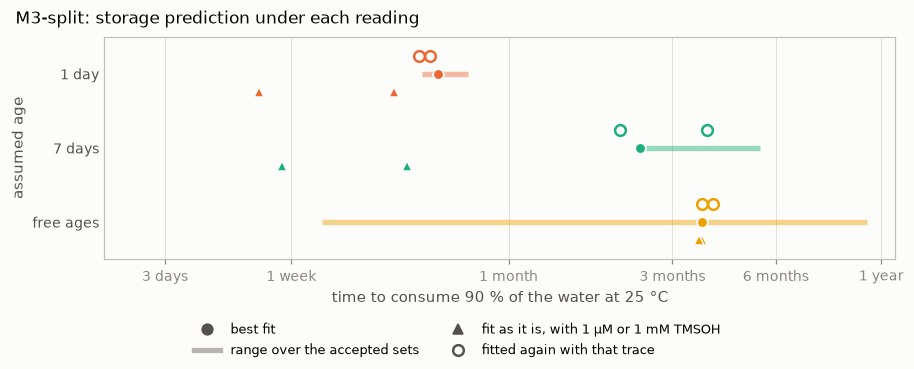

In [50]:
storage, seeded = read('prediction_storage.csv'), read('prediction_storage_traces.csv')
fit_plots.plot_storage_ranges(storage, seeded, structure=MAIN, scenarios=FITTING, title=f'{MAIN}: storage prediction under each reading');
days = of_main(storage).set_index('scenario').loc[list(FITTING)].rename(index=AGES)
display(pd.DataFrame({'best fit (days)': (days['t90 water (h), best fit'] / 24).round(0), 'accepted sets, from (days)': (days['band low (h)'] / 24).round(0),
                      'to (days)': (days['band high (h)'] / 24).round(0), 'TMSPA left after 1 year': days['TMSPA left after 1 year, best fit'].round(2)})
        .rename_axis('reading'))
seeded = of_main(seeded).assign(reading=lambda d: d['scenario'].map(AGES), trace=lambda d: d['TMSOH at mixing (M)'].map(show_M))
(seeded.set_index(['reading', 'trace'])[[c for c in seeded.columns if c.startswith('t90')]] / 24).round(0).rename(columns=lambda c: c.replace('t90 water (h), ', '')).rename_axis(
    index=['reading', 'TMSOH at mixing'], columns='days to consume 90 % of the water')

**Result**

- **Best fits:** 90 % of the water is gone after 19 days (1 day), 72 days (7 days) or 109 days (free ages). Over the accepted sets: 17–23, 72–162 and 9–331 days. Together that is between 9 days and 11 months.
- **The 7-day range is too wide as stored** (A.3). With the accepted sets of 3.2 it is 72–136 days (checked outside the result files).
- **The equal-age numbers move with a trace of TMSOH.** The 1-day fit gives 19 days from the recipe alone, 14 days with 1 µM and 6 days with 1 mM. The 7-day fit gives 72, 15 and 7 days. The free-age fit stays at 107–109 days.
- **After one year about a quarter of the TMSPA is left under every reading (0.27–0.28).** This is set by the amount of water (20 mM for 50 mM TMSPA) and the fitted energies, not by the barriers. It is the most stable number here.
- **What the prediction rests on:** barriers seen at 22 °C in two water tubes of unknown age, applied at 25 °C to a recipe with 13 to 53 times less water.

--> The storage time is known to a factor of forty. The amount of TMSPA left at the end is known better than the time it takes.

### 6.2 The bench protocol and the temperature

- **Case:** the protocol holds the sample at 20, 30, … 80 °C and records a spectrum after each hold. The question is how much TMSPA is left at each one.
- **Blind spot:** hydrolysis and transfer were seen at 22 °C only, and every fit sets ΔS‡ = 0. Here the best fit is rerun with ΔS‡ from −150 to +50 J mol⁻¹ K⁻¹, each barrier anchored at the temperature where it was observed.

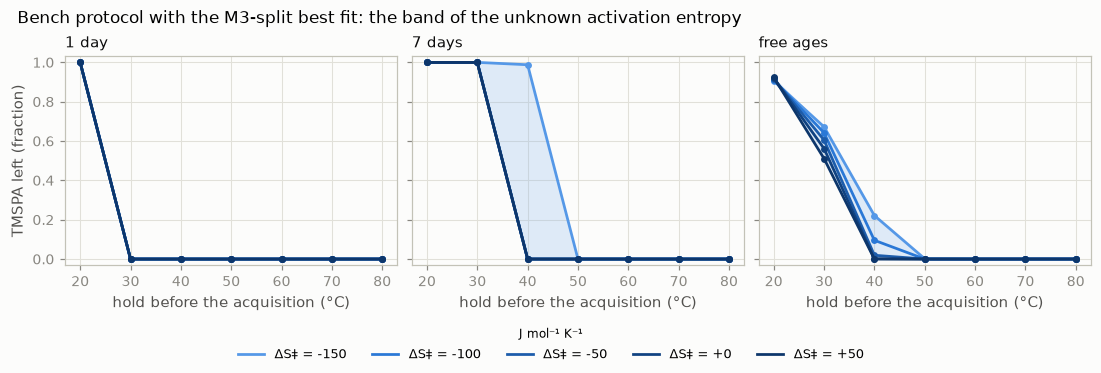

In [51]:
protocol = read('prediction_protocol.csv')
fit_plots.plot_protocol_band(protocol, structure=MAIN, scenarios=FITTING, labels=fit_plots.AGE_LABELS);

**Result**

- **The reading decides the prediction, not the activation entropy.**
  - 1-day fit: all TMSPA is there at 20 °C and none at 30 °C, for every ΔS‡. The cliff of 3.4 falls between the two.
  - 7-day fit: all TMSPA survives 20 and 30 °C and is gone at 40 °C (at 50 °C for the most negative ΔS‡).
  - Free ages: 0.91–0.93 is left at 20 °C, 0.51–0.67 at 30 °C and 0–0.22 at 40 °C.
- **The band of ΔS‡ is narrow because TMSPA is gone close to where the barriers were measured.** All three fits consume it by 40–50 °C, within 20–30 K of 22 °C.
- **The temperature blind spot is elsewhere.** At the 60–80 °C holds the fits act only through condensation and solvent attack, on a mixture that has already reacted. Hydrolysis and transfer at 60–80 °C are never tested.
- **Against `reference_bep`:** 1.15 eV spreads the consumption of TMSPA over the 20–80 °C holds by construction. No fit here does: each consumes it within one or two holds.

--> Both predictions inherit the open question of §4: how TMSPA is consumed.

## 7. What is known, what is not, what next

**Known: the same under the three readings, with or without a trace, and under every declared variant** (§5.6)

- **Structure:** no single barrier, and no barrier per family with the computed energies, describes the tubes. At equal ages R1 has to be separate from R2–R3.
- **Solvent attack:** ΔG‡(R8) = 1.29 eV at 80 °C (±0.02 more if the glovebox hold was 4 h or 16 h). No single tube moves it.
- **Condensation\*:** ΔG‡(R4) = 1.24 eV at 80 °C (same remark). It falls to 1.18 eV when the glovebox or the 2 % tube is left out.
- **Second and third hydrolysis\*:** ΔG‡(R2) = 0.93–1.08 eV and ΔG‡(R3) = 0.95–1.10 eV at 22 °C.
- **Reaction energies\*:** R1 −0.05 eV, R2 +0.03 to +0.05 eV, R3 +0.07 to +0.09 eV, R4 −0.14 to −0.18 eV.

\* If at least 60 % of the water added to the 2 % tube took part (§5.4).

**Not known**

| Open point | Why it is open | What would close it |
|---|---|---|
| How TMSPA is consumed: ΔG‡(R1) 1.08–1.67 eV, ΔG‡(R5) 0.43–0.94 eV | the ages and the TMSOH present at mixing decide (3.4, 4.2); the one tube seen in time is not fitted (4.3) | "TMSPa alone" in the fit; better, one tube followed in time at 22 °C from a known mixing time |
| Whether the 2 % tube rests at an equilibrium or ran out of water | a fraction near 0.2 and any fraction above 0.6 fit (5.4) | the water content of the tube, which no spectrum here measures |
| The temperature dependence of hydrolysis and transfer | seen at 22 °C only (6.2) | the same recipe at a second temperature |
| The shape of the barrier relation | the reactions seen are close to thermoneutral, where Marcus and Agmon–Levine coincide (5.5) | not testable with these tubes |
| Whether any barrier except solvent attack is right | each of the others rests on one or two tubes (5.3) | a second tube for each reaction |

**What next: the third fit** ([plan-fit_improvement.md](../docs/plan-fit_improvement.md))

| # | Change | Reason in this notebook |
|---|---|---|
| C1 | Free ages become the base reading; equal ages stay as a sensitivity run | 4.2: only the free-age fit survives a trace |
| C2 | "TMSPa alone" enters the fit, with its water content as an unknown | 4.3: it is what the free-age fit gets wrong, and the only tube seen in time |
| C3 | Every fit must also hold with a trace of TMSOH at mixing | 4.2: a fit that a trace destroys says nothing about the barriers |

- **Aim:** the transfer barrier, today only bounded from above, gets a value (0.7–0.8 eV in the screening of the plan).
- **Not changed:** the reaction network, the barrier shape, the four free reaction energies and the error model.

**Decisions left to the author**

- **A fitted model in the registry.** By the rule fixed before fitting, the first consistent set is M3-split at equal ages: 7 days (χ² 32.4) by the lower χ², 1 day (32.7) just behind. Nothing was written into the registry, because both rest on the waiting time that a trace removes (4.2) and the free-age set fails TMSPa alone (4.3). `build_fitted_model` builds any of them from its result file.

**Open in the result files and in the spectra**

- The ranges over the accepted sets of the 7-day reading are too wide as stored, because the χ² of that fit depends on the solver tolerance (A.3). They are rebuilt here for the barriers; the storage range of 6.1 is not.
- The ³¹P region near −144 ppm (PF₆⁻) in every TMSPa tube, not only the 0.5 % one.
- The ¹⁹F spectrum of the glovebox TMSOH tube.
- The clock times and durations of the heating steps of the 2 % tube (17–18 min assumed, 8 h stated in the paper; 5.5 shows what changes).

---

## Appendix: complete tables

Reference material behind the steps above, with the scenario names of the result files (`short` = 1 h, `middle` = 1 day, `long` = 7 days, `free` = free ages).

### A.1 Fitted parameters of every structure

The fitted parameters themselves: the intrinsic barriers g (eV), the shifts of ΔG_rxn (eV) and the age of the 2 % tube (log₁₀ of hours) where it is free. χ² and the worst miss of every structure are in 2.1.

In [52]:
parameters.set_index(['structure', 'scenario']).reindex([(s, sc) for s in LADDER for sc in AGES]).round(3).fillna('—')

g all reactions log10 age 2 % H2O g hydrolysis g transfer  \
structure scenario                                                             
M0-BEP    short              1.278                 —            —          —   
          middle             1.278                 —            —          —   
          long               1.276                 —            —          —   
          free                1.22             2.857            —          —   
M0-Marcus short              1.468                 —            —          —   
          middle             1.466                 —            —          —   
          long               1.458                 —            —          —   
          free               1.436             2.857            —          —   
M1        short                  —                 —        0.986      1.026   
          middle                 —                 —        1.076      1.028   
          long                   —                 —        1.401      0.676   
          free                   —             2.857        1.309      0.904   
M1-split  short                  —                 —            —      1.067   
          middle                 —                 —            —      1.077   
          long                   —                 —            —      1.091   
          free                   —             2.857            —       1.05   
M3        short                  —                 —        0.903      0.695   
          middle                 —                 —        0.957      0.629   
          long                   —                 —        0.995      0.706   
          free                   —             2.857        1.016      0.892   
M3-split  short                  —                 —            —      0.633   
          middle                 —                 —            —      0.683   
          long                   —                 —            —      0.647   
          free                   —             2.723            —      1.011   

                   g condensation g solvent_attack g hydrolysis_R1  \
structure scenario                                                   
M0-BEP    short                 —                —               —   
          middle                —                —               —   
          long                  —                —               —   
          free                  —                —               —   
M0-Marcus short                 —                —               —   
          middle                —                —               —   
          long                  —                —               —   
          free                  —                —               —   
M1        short              1.12            1.306               —   
          middle            1.696            1.304               —   
          long              1.087            1.303               —   
          free               1.15            1.296               —   
M1-split  short             1.651            1.306            1.17   
          middle            1.509            1.306           1.541   
          long              1.625            1.306           1.414   
          free              1.665            1.306           1.311   
M3        short             1.272            1.311               —   
          middle            1.301            1.308               —   
          long              1.333             1.31               —   
          free               1.43             1.31               —   
M3-split  short              1.27            1.311           0.945   
          middle            1.308             1.31           1.341   
          long              1.312             1.31           1.691   
          free              1.327             1.31            1.11   

                   g hydrolysis_R23  dG R1  dG R2  dG R3  dG R4  
structure scenario                                 

### A.2 Every miss of every structure

All 73 values (77 with the freed energies) at 1 day and with free ages. The number is the miss; bold where it is above 3. The "no change" rows show the largest of each peak.

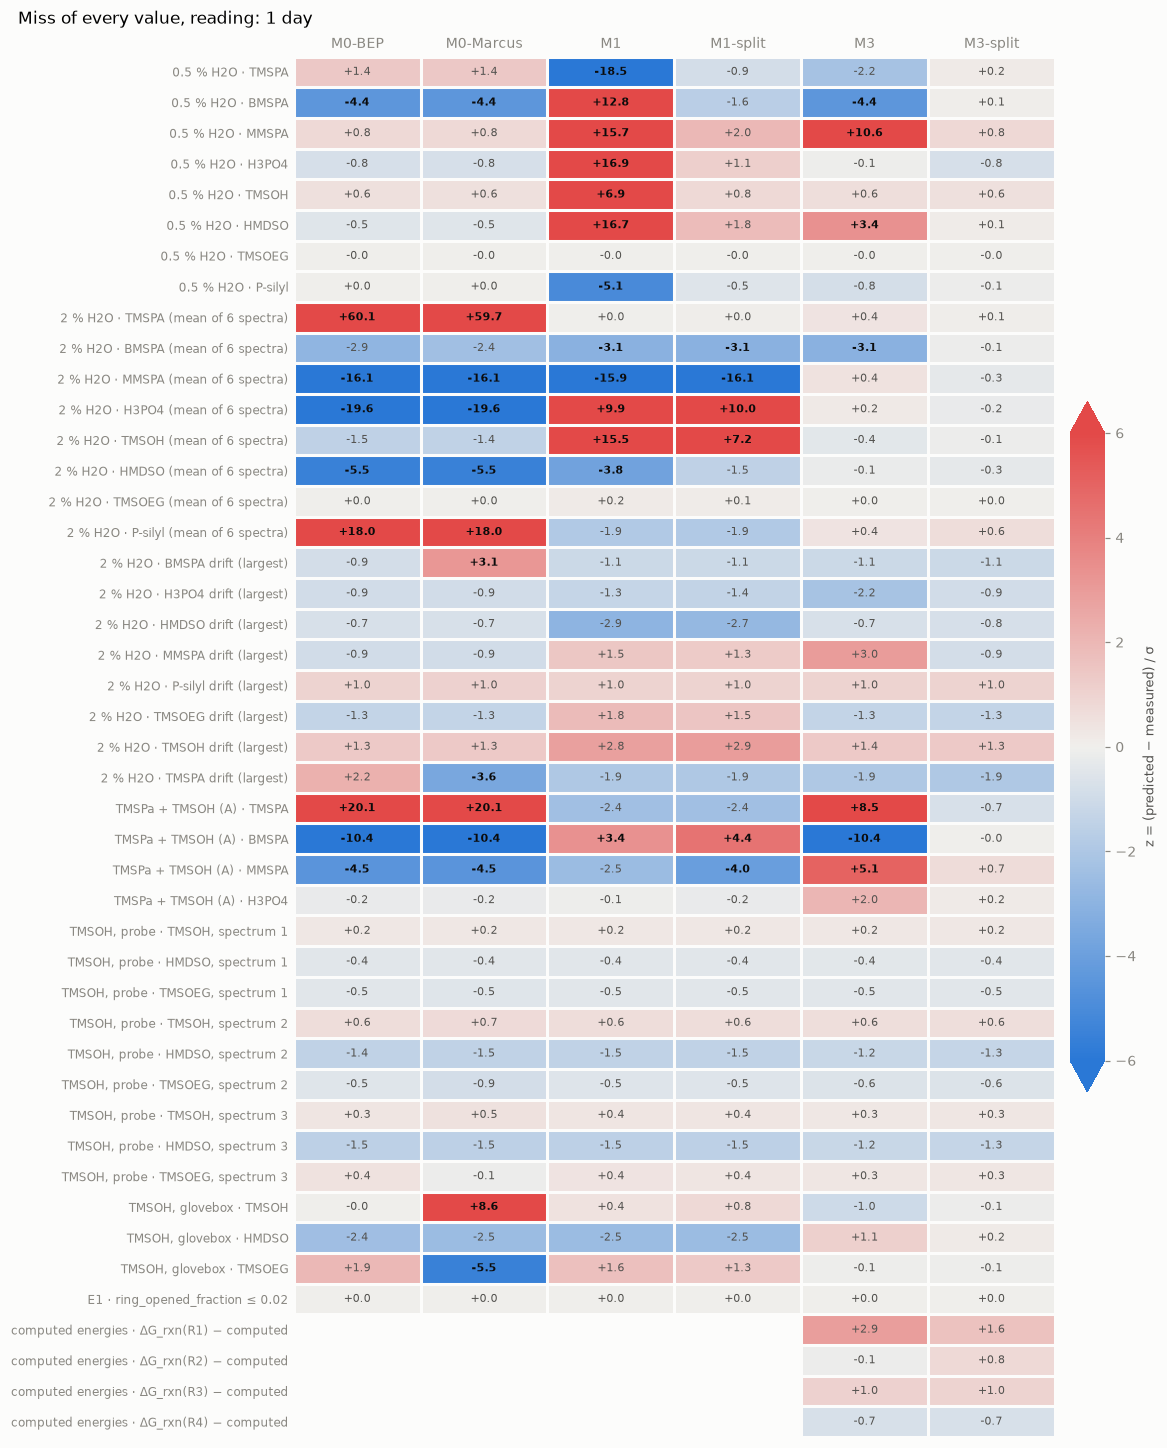

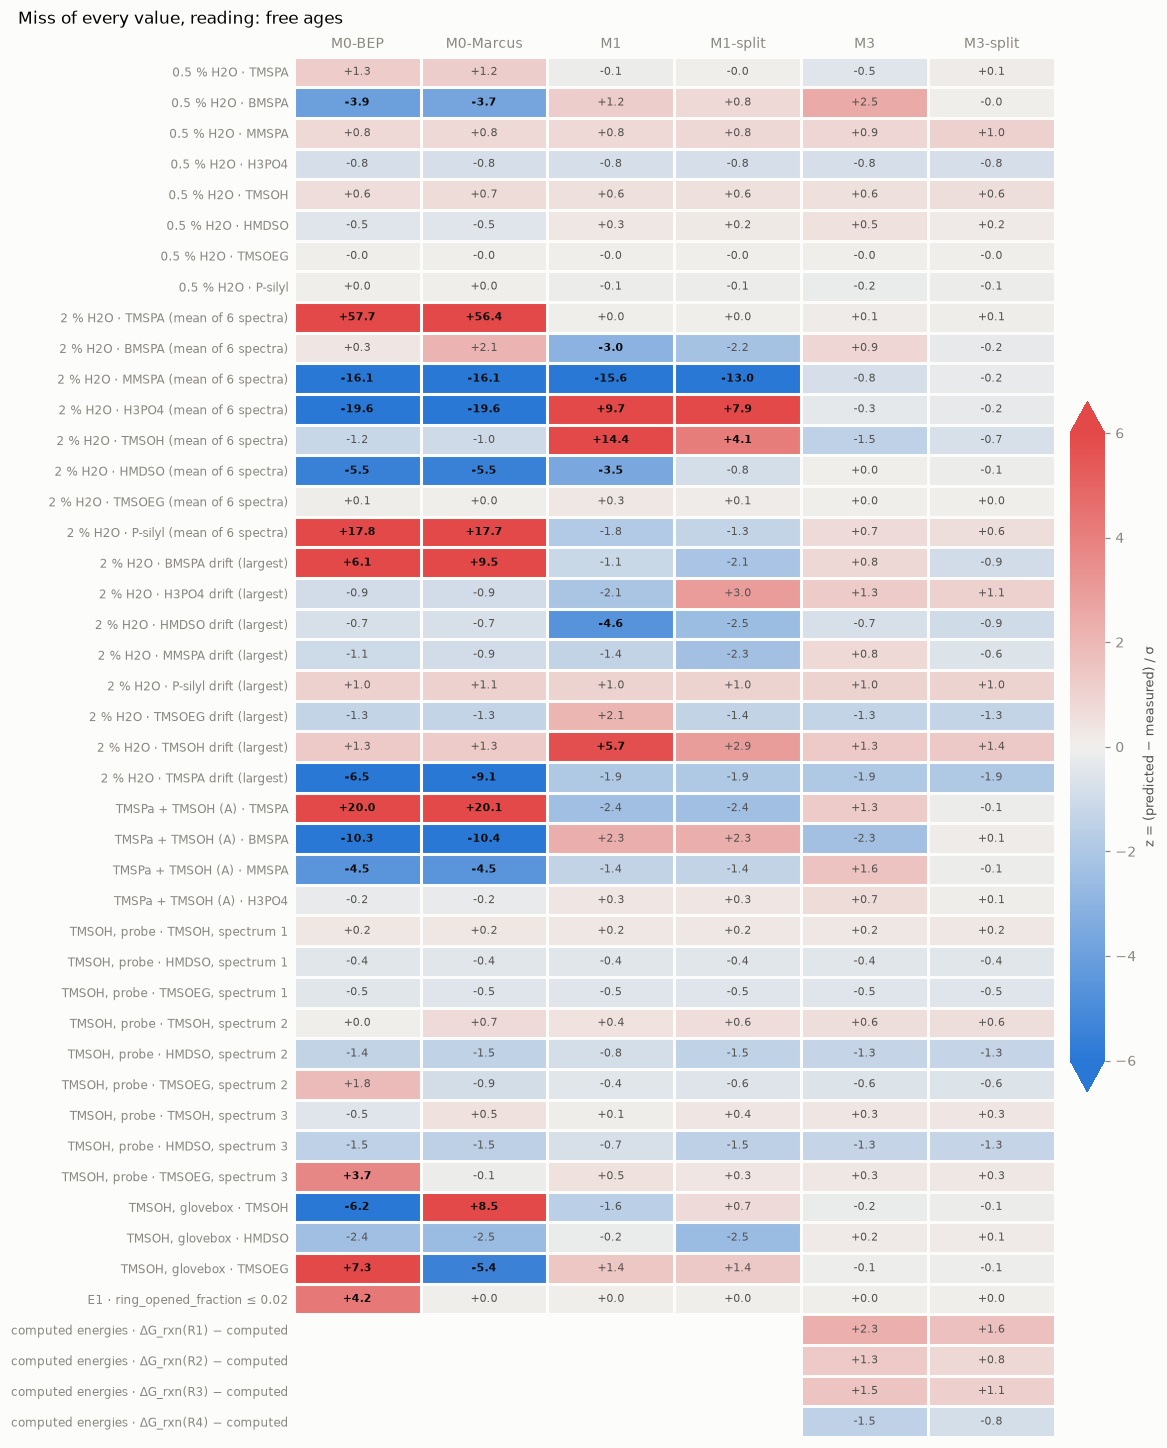

In [53]:
for scenario in ('middle', 'free'):
    fit_plots.plot_residual_map(residuals, scenario=scenario, order=LADDER, title=f'Miss of every value, reading: {AGES[scenario]}')

### A.3 Profiles, and the accepted sets of the 7-day reading

- **Table:** how many profile points count as accepted sets, by two measures.
- **Figures:** the fitted parameters of M3-split under the four readings with their 95 % intervals (§5.2), and the profiles they are read from.

**Why the 7-day ranges are rebuilt in this notebook**

- The accepted sets are the profile points within Δχ² = 3.84 of the fit. The stored profile keeps Δχ² in its column `delta`.
- For the 7-day reading `delta` is measured against χ² 47.5. That is the χ² of the 7-day fit at the solver tolerance of the search (rtol 10⁻⁶). At the report tolerance (rtol 10⁻⁸) the same fit has χ² 32.4. (The two evaluations were made outside the result files, 2026-10-07.)
- The 1-day and the free-age fit have the same χ² at both tolerances. Only the 7-day fit moves, by 15. It is also the fit that 1 nM of TMSOH breaks (4.2): the timing of its cliff depends on amounts this small.
- So `barrier_bands.csv` and the storage range count 14 sets that lie 3.9 to 14.9 above the fit. This widens condensation from 1.23–1.26 to 1.21–1.55 eV and transfer from 0.48–0.70 to 0.48–0.86 eV.
- The intervals of §5.2 are not affected: they are read from the lowest χ² of each profile.
- Here the 7-day ranges are taken against the χ² of the fit at the report tolerance (`tabulate_accepted_ranges` in the first cell). For 1 day and free ages the two measures give the same sets.

,1 h,1 day,7 days,free ages
χ² of the fit,659.5,32.7,32.4,30.4
χ² that `delta` is measured against,659.5,32.7,47.5,30.4
profile points,76.0,211.0,125.0,252.0
accepted by `delta` (as stored),19.0,150.0,91.0,179.0
within 3.84 of the fit (used here),19.0,150.0,77.0,179.0


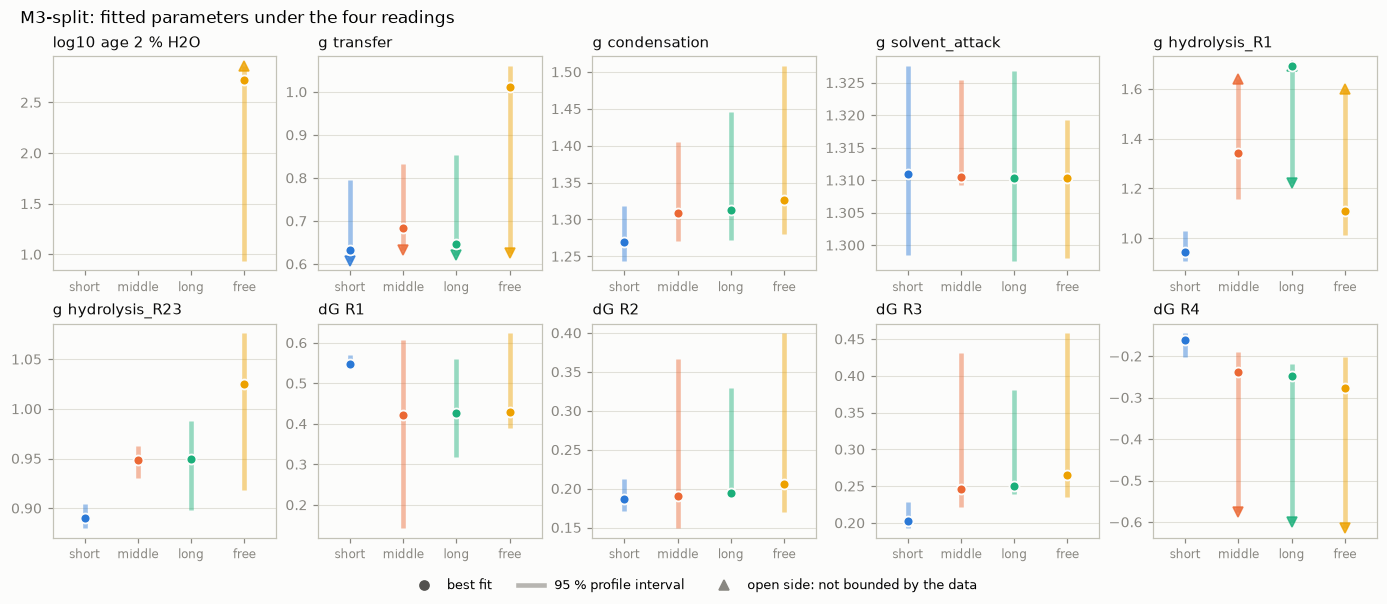

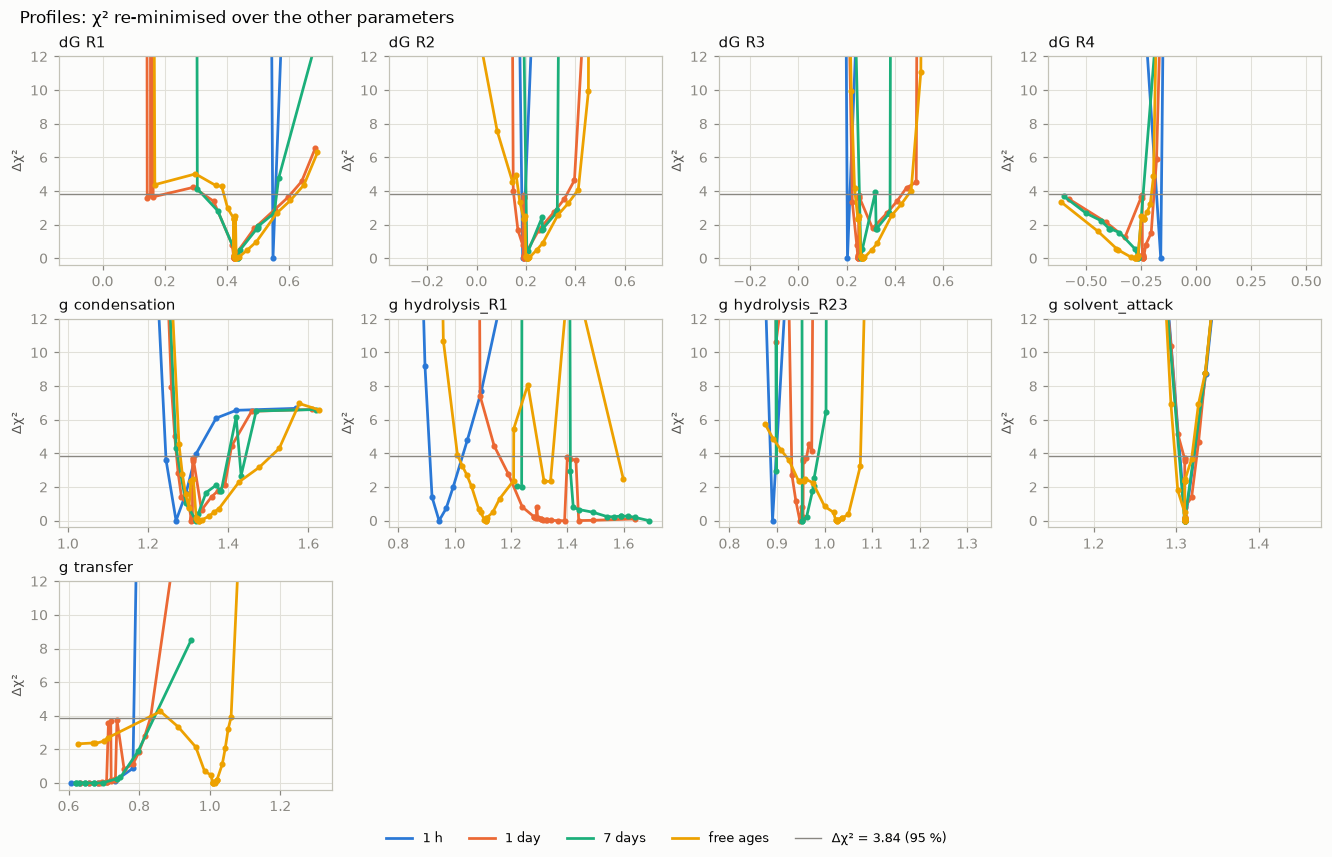

In [54]:
profiles = {scenario: load_fit_result(str(RESULTS / 'profiles' / f'{MAIN}__{scenario}.json'))['profile'] for scenario in AGES}
fit_chi2 = summary[summary['structure'] == MAIN].set_index('scenario')['chi2']
display(pd.DataFrame({AGES[scenario]: {'χ² of the fit': round(fit_chi2[scenario], 1), 'χ² that `delta` is measured against': round((p['chi2'] - p['delta']).iloc[0], 1),
                                       'profile points': len(p), 'accepted by `delta` (as stored)': int((p['delta'] <= DELTA_CHI2).sum()),
                                       'within 3.84 of the fit (used here)': int((p['chi2'] - fit_chi2[scenario] <= DELTA_CHI2).sum())}
                      for scenario, p in profiles.items()}))
fit_plots.plot_fit_across_scenarios(parameters, intervals, structure=MAIN, title=f'{MAIN}: fitted parameters under the four readings');
fit_plots.plot_profiles(profiles, labels=fit_plots.AGE_LABELS);

### A.4 Combinations of parameters that the data see

Each row is one combination of the parameters of M3-split at the best fit, with the standard error the data give along it. Large values are directions the data do not determine. These are statements at the best fit only; the profiles of A.3 hold away from it.

- **1 day:** one combination is held to 0.4 meV: the barrier of R2–R3 together with ΔG_rxn(R2), which is the timing of the cliff against the single spectrum of the 0.5 % tube. It says how sharply this fit depends on that spectrum, not how precisely anything was measured. Two combinations of the R1 and transfer barriers are not held (0.3 and 1.7 eV).
- **Free ages:** all nine combinations are held, to 2–91 meV. The widest one moves the four reaction energies together and is held mostly by the computed values.

In [55]:
def show_meV(value_eV):
    return 'over 1 000' if value_eV > 1.0 else f'{1000 * value_eV:.1f}'


for scenario in ('middle', 'free'):
    directions = load_fit_result(str(RESULTS / 'profiles' / f'{MAIN}__{scenario}.json'))['directions']
    display(directions.drop(columns='sigma_eV').round(2).set_index(directions['sigma_eV'].map(show_meV).rename(f'{AGES[scenario]}: standard error along the combination (meV)')))

,g hydrolysis_R1,g hydrolysis_R23,g transfer,g condensation,g solvent_attack,dG R1,dG R2,dG R3,dG R4
1 day: standard error along the combination (meV),,,,,,,,,
0.4,-0.18,-0.93,-0.12,0.00,0.00,-0.09,-0.29,-0.05,0.06
2.2,-0.00,-0.02,-0.00,0.01,-0.00,-0.00,0.02,0.89,0.45
6.7,0.00,0.00,0.00,-0.02,1.00,0.00,-0.01,0.00,-0.01
7.6,0.04,0.21,0.03,-0.06,-0.01,0.28,-0.87,0.18,-0.31
12.8,-0.01,-0.06,-0.01,-0.87,-0.02,-0.21,0.15,0.19,-0.38
18.8,0.02,0.09,0.01,0.35,0.00,-0.85,-0.13,0.16,-0.31
60.7,0.01,0.20,0.00,-0.35,0.00,-0.38,-0.35,-0.33,0.68
301.7,-0.71,0.21,-0.67,0.01,0.00,0.01,0.01,0.01,-0.02
over 1 000,0.68,-0.04,-0.73,-0.00,-0.00,-0.00,-0.00,-0.00,0.00


,g hydrolysis_R1,g hydrolysis_R23,g transfer,g condensation,g solvent_attack,dG R1,dG R2,dG R3,dG R4
free ages: standard error along the combination (meV),,,,,,,,,
2.0,-0.00,-0.09,0.07,-0.00,0.00,-0.00,-0.02,-0.89,-0.45
6.7,-0.00,0.01,-0.01,0.02,-1.00,-0.00,0.00,-0.01,0.01
8.0,0.40,0.17,-0.15,-0.04,-0.00,0.48,-0.71,0.09,-0.20
8.5,-0.33,0.70,-0.58,-0.02,0.01,-0.22,-0.03,-0.08,-0.07
9.2,-0.64,-0.28,0.16,-0.07,-0.01,-0.29,-0.57,0.16,-0.21
13.1,0.11,0.01,0.01,-0.90,-0.02,-0.06,0.19,0.17,-0.33
23.6,0.52,-0.01,-0.02,0.26,0.00,-0.71,-0.08,0.17,-0.34
47.2,-0.05,0.62,0.77,0.06,-0.00,0.02,0.01,0.06,-0.11
90.6,0.19,0.08,0.11,-0.34,0.00,-0.35,-0.34,-0.34,0.69


### A.5 Protocol prediction as numbers, and the solver tolerance

TMSPA left at each hold of the bench protocol for each ΔS‡ (§6.2), and two profile intervals of the 1-day reading repeated at a tighter solver tolerance: the edges move by at most 0.013 eV.

In [56]:
display(of_main(protocol).pivot_table(index=['scenario', 'dS (J/mol/K)'], columns='hold T (°C)', values='TMSPA left').loc[list(FITTING)].round(3))
read('tolerance_check.csv').round(4)

hold T (°C)             20.0   30.0   40.0   50.0  60.0  70.0  80.0
scenario dS (J/mol/K)                                              
middle   -150.0        1.000  0.000  0.000  0.000   0.0   0.0   0.0
         -100.0        1.000  0.000  0.000  0.000   0.0   0.0   0.0
         -50.0         1.000  0.000  0.000  0.000   0.0   0.0   0.0
          0.0          1.000  0.000  0.000  0.000   0.0   0.0   0.0
          50.0         1.000  0.000  0.000  0.000   0.0   0.0   0.0
long     -150.0        1.000  1.000  0.988  0.000   0.0   0.0   0.0
         -100.0        1.000  1.000  0.000  0.000   0.0   0.0   0.0
         -50.0         1.000  1.000  0.000  0.000   0.0   0.0   0.0
          0.0          1.000  1.000  0.000  0.000   0.0   0.0   0.0
          50.0         1.000  1.000  0.000  0.000   0.0   0.0   0.0
free     -150.0        0.906  0.672  0.221  0.002   0.0   0.0   0.0
         -100.0        0.911  0.642  0.095  0.000   0.0   0.0   0.0
         -50.0         0.916  0.605  0.019  0.000   0.0   0.0   0.0
          0.0          0.920  0.562  0.002  0.000   0.0   0.0   0.0
          50.0         0.925  0.511  0.000  0.000   0.0   0.0   0.0

,parameter,"low, rtol 1e-6","low, rtol 1e-8","high, rtol 1e-6","high, rtol 1e-8","status, rtol 1e-6","status, rtol 1e-8"
0,g solvent_attack,1.3093,1.3093,1.3254,1.3255,interval,interval
1,g hydrolysis_R23,0.9303,0.9174,0.9626,0.9624,interval,interval


### A.6 First and second fit side by side

χ² (worst miss) of every structure in the two fits. The χ² values are not comparable between the fits: the first is scored on 45 values (49 with the freed energies), the second on 73 (77). The verdicts are: the same structures fit, except M3 with free ages, which now passes.

In [57]:
pd.concat({'first fit (45 values)': tables.format_structure_table(pd.read_csv(FIRST / 'fits_summary.csv')),
           'second fit (73 values)': tables.format_structure_table(summary)}, axis=1).rename(columns=AGES, level=1).drop(columns='free parameters', level=1)

first fit (45 values)                 \
χ² (largest |z|), ✓ = no |z| above 3                   1 h          1 day   
M0-BEP                                       3634 (60.1) ✗  3634 (60.1) ✗   
M0-Marcus                                    3690 (59.8) ✗  3687 (59.7) ✗   
M1                                           1067 (20.1) ✗   343 (16.1) ✗   
M1-split                                     1021 (20.1) ✗   301 (16.0) ✗   
M3                                            536 (11.6) ✗   294 (16.1) ✗   
M3-split                                      535 (11.6) ✗     20 (1.9) ✓   

                                                                    \
χ² (largest |z|), ✓ = no |z| above 3         7 days      free ages   
M0-BEP                                3630 (60.0) ✗  3630 (60.0) ✗   
M0-Marcus                             3670 (59.4) ✗  3670 (59.4) ✗   
M1                                     320 (16.0) ✗   301 (16.0) ✗   
M1-split                               291 (15.4) ✗   282 (15.0) ✗   
M3                                       60 (4.1) ✗     27 (3.1) ✗   
M3-split                                 20 (1.9) ✓     19 (1.9) ✓   

                                     second fit (73 values)                 \
χ² (largest |z|), ✓ = no |z| above 3                    1 h          1 day   
M0-BEP                                        3914 (60.1) ✗  3913 (60.1) ✗   
M0-Marcus                                     3968 (59.8) ✗  3965 (59.7) ✗   
M1                                            1698 (21.0) ✗  1579 (18.5) ✗   
M1-split                                      1543 (22.0) ✗   412 (16.1) ✗   
M3                                             665 (13.5) ✗   324 (10.6) ✗   
M3-split                                       660 (13.4) ✗     33 (1.9) ✓   

                                                                    
χ² (largest |z|), ✓ = no |z| above 3         7 days      free ages  
M0-BEP                                3909 (60.0) ✗  3848 (57.7) ✗  
M0-Marcus                             3947 (59.3) ✗  3821 (56.4) ✗  
M1                                     677 (19.7) ✗   561 (15.6) ✗  
M1-split                               379 (15.9) ✗   275 (13.0) ✗  
M3                                     261 (10.4) ✗     49 (2.5) ✓  
M3-split                                 32 (1.9) ✓     30 (1.9) ✓